In [1]:
# === FASE 1. IMPORTACIÓN DE LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
import itertools
import networkx as nx
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud
import re


# Ensure the column is datetime
#_col = '2025-10-14 02:20:34'
#if _col in df_form.columns:
   # _dt_series = pd.to_datetime(df_form[_col], errors='coerce')

    # Define the range (order-agnostic)
    #_a = pd.to_datetime('2025-10-09 13:17:29')
    #_b = pd.to_datetime('2025-10-09 07:40:53')
    #_start, _end = (min(_a, _b), max(_a, _b))

    # Drop rows where the datetime falls within [start, end]
    #_mask_drop = _dt_series.between(_start, _end, inclusive='both')
    #df_form = df_form.loc[~_mask_drop].copy()

    # Clean up temp vars
    #del _dt_series, _a, _b, _start, _end, _mask_drop
#else:
  # raise KeyError(f"La columna {_col!r} no existe en df_form")


In [2]:
# Carpeta con los archivos de Excel
folder_path = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Alexandra_aporte_BDT"

# Extensiones de Excel que queremos leer
excel_extensions = (".xlsx", ".xls", ".xlsm", ".xlsb")

for file_name in os.listdir(folder_path):
    if file_name.lower().endswith(excel_extensions):
        file_path = os.path.join(folder_path, file_name)
        print("=" * 80)
        print(f"Leyendo archivo: {file_name}")
        try:
            df = pd.read_excel(file_path)
            print("\nINFO DEL DATAFRAME:")
            df.info()
            print("\nPRIMERAS FILAS (head):")
            df.shape
            print("\nDIMENSIONES DEL DF")
            display(df.head())  # display para ver mejor en Jupyter
        except Exception as e:
            print(f"Error al leer {file_name}: {e}")

print("\nProceso terminado.")


Leyendo archivo: BASE DE DATOS TULUA.xlsx

INFO DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 9 columns):
 #   Column                                                                                                                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                        --------------  ----- 
 0   Unnamed: 0                                                                                                                                                                                                                    170 non-null    object
 1   BASE DE DATOS JUNTAS DE ACCION COMUNAL TULUA                                  

,Unnamed: 0,BASE DE DATOS JUNTAS DE ACCION COMUNAL TULUA SECRETARIA PRIVADA,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Código:\nF-280-09
0,NaN,NaN,NaN,NaN,NaN,Fecha de aprobación: 15 de junio de 2021,NaN,NaN,Página 1 de 1
1,NUMERO,BARRIO O URBANIZACION,NaN,SECTOR,COMUNA,REPRESENTANTE\nLEGAL,No. CELULAR O TELEFONOS FIJOS,NaN,CORREOS ELECTRONICOS
2,1,URBANIZACION,NaN,ALAMEDA I,9,JHON ARGEMIROM VELEZ GARRIDO,313-766-7701 312-763-8348,NaN,MANIFIESTA NO TENER
3,2,URBANIZACION,NaN,ALAMEDA II,9,ROSA AMALIA RIASCOS BASTIDAS,3152133687 -318-509-5871,NaN,rosita-bastidas@hotmail.com
4,3,BARRIO,NaN,AVENIDA CALI,5,MARTHA LILIANA CAICEDO,3154708932,NaN,marli_caicedo@yahoo.com


Leyendo archivo: ciclo 1 RptLiquidacionIva Tulua (1).xlsx

INFO DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1739 non-null   object 
 1   Unnamed: 1     1 non-null      object 
 2   Unnamed: 2     1738 non-null   object 
 3   Unnamed: 3     1738 non-null   object 
 4   Unnamed: 4     0 non-null      float64
 5   Unnamed: 5     0 non-null      float64
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     1 non-null      object 
 8   Unnamed: 8     1738 non-null   object 
 9   Unnamed: 9     1 non-null      object 
 10  Unnamed: 10    1 non-null      object 
 11  Unnamed: 11    1738 non-null   object 
 12  Unnamed: 12    1738 non-null   object 
 13  Unnamed: 13    0 non-null      float64
 14  Unnamed: 14    0 non-null      float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    17

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,PAGINA 1 DE 1
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LISTADO DE LIQUIDACIÒN IVA\nPOR MUNICIPIO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Leyendo archivo: CONSOLIDADO PENDIENTES.xlsx

INFO DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1439 entries, 0 to 1438
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   pri_nom_informante    1439 non-null   object
 1   seg_nom_informante    965 non-null    object
 2   pri_ape_informante    1439 non-null   object
 3   seg_ape_informante    1320 non-null   object
 4   Tip_informante        1439 non-null   int64 
 5   ide_firma_informante  1354 non-null   object
 6   Cau_sin_firma         1439 non-null   int64 
 7   Email_contacto        729 non-null    object
 8   num_tel_contacto      1439 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 101.3+ KB

PRIMERAS FILAS (head):

DIMENSIONES DEL DF


...

Leyendo archivo: LISTADO DE TALLERES Y CAPACITACIONES.xlsx

INFO DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   TALLERES Y CAPACITACIONES   103 non-null    object
 1   Unnamed: 1                  103 non-null    object
 2   Unnamed: 2                  103 non-null    object
 3   Unnamed: 3                  70 non-null     object
 4   Unnamed: 4                  69 non-null     object
 5   Unnamed: 5                  66 non-null     object
 6   Unnamed: 6                  55 non-null     object
 7   Unnamed: 7                  72 non-null     object
 8   Unnamed: 8                  66 non-null     object
 9   Unnamed: 9                  1 non-null      object
dtypes: object(10)
memory usage: 8.2+ KB

PRIMERAS FILAS (head):

DIMENSIONES DEL DF


,TALLERES Y CAPACITACIONES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NOMBRE,TELEFONO,CEDULA,AMOR PROPIO,EMP. FEMENINO,LIDERAZGO,AUTOESTIMA,VIOLENCIAS DE GENERO,FINANZAS PERSONALES,EMPRENDIMIENTO
2,ADIELA RODRIGUEZ,3164416583,38869609,X,NaN,NaN,X,X,X,NaN
3,ALEXANDRA ARIAS,3115665926,1116257059,X,X,NaN,NaN,X,X,NaN
4,LUZ DARY CAMACHO,3206250674,31952389,X,NaN,NaN,NaN,NaN,NaN,NaN


Leyendo archivo: Ministerio de Salud y Protección Social (5 integrantes).xlsx

INFO DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Columns: 187 entries, Id to 100. ¿Como se realiza la disposición final de los residuos sólidos ordinarios de la vivienda?
dtypes: datetime64[ns](8), float64(2), int64(1), object(176)
memory usage: 3.6+ MB

PRIMERAS FILAS (head):

DIMENSIONES DEL DF


,Id,Hora de inicio,Hora de finalización,Correo electrónico,Nombre,Departamento,UZPE - Unidad Zonal de Planeación y Evaluación - Regional - Provincia,Municipio / Área no municipalizada,Territorio (ID - Serial),Microterritorio (ID - Serial),...,92. ¿Cuál fuente de energía o combustible que se usa para cocinar?,93. ¿Se observa cerca de la vivienda o dentro de ella criaderos o reservorios que pueden favorecer la presencia de vectores transmisores de enfermedades?,94. Observe si cerca de la vivienda hay alguno de los siguientes:,95. ¿Al interior de la vivienda se realiza alguna actividad económica?,"96. Señale los animales que conviven con la familia dentro de la vivienda o en su entorno inmediato, e indique cuantos son:\n",96.2 Registrar Cantidad de animas que conviven con la familia:,97. ¿Cuál es la principal fuente de abastecimiento de agua para consumo humano en la vivienda?,98. ¿Cuál es el sistema de disposición de excretas en la vivienda?,99. ¿Cuál es el sistema de disposición de aguas residuales domésticas en la vivienda?,100. ¿Como se realiza la disposición final de los residuos sólidos ordinarios de la vivienda?
0,1,2024-08-08 14:48:50,2024-08-08 15:00:25,anonymous,NaN,Valle del Cauca,UZPE002,Tuluá,T04,MT01,...,2. Gas natural,SI,1. Cultivos;3. Porquerizas;4. Galpones;5. Terr...,No,1. Perros;2. Gato;,4,1. Acueducto administrado por empresa prestado...,1. Sanitario conectado al alcantarillado,1. Alcantarillado,1. Recolección por parte del servicio de aseo ...
1,2,2024-08-08 14:44:36,2024-08-08 15:02:12,anonymous,NaN,Valle del Cauca,UZPE002,Tuluá,T04,MTI01,...,2. Gas natural,No,7. Ruido o sonidos desagradables;,SI,1. Perros;2. Gato;,2,1. Acueducto administrado por empresa prestado...,1. Sanitario conectado al alcantarillado,1. Alcantarillado,1. Recolección por parte del servicio de aseo ...
2,3,2024-08-08 14:37:45,2024-08-08 15:07:38,anonymous,NaN,Valle del Cauca,UZPE002,Tuluá,T04,MT01,...,1. Electricidad,SI,NaN,No,1. Perros;2. Gato;,2 perros 2 gatos,1. Acueducto administrado por empresa prestado...,1. Sanitario conectado al alcantarillado,1. Alcantarillado,1. Recolección por parte del servicio de aseo ...
3,4,2024-08-08 15:08:59,2024-08-08 15:19:13,anonymous,NaN,Valle del Cauca,UZPE002,Tuluá,T04,MT01,...,2. Gas natural,No,1. Cultivos;5. Terrenos baldíos;7. Ruido o son...,No,1. Perros;,1,1. Acueducto administrado por empresa prestado...,1. Sanitario conectado al alcantarillado,1. Alcantarillado,1. Recolección por parte del servicio de aseo ...
4,5,2024-08-08 14:53:11,2024-08-08 15:21:21,anonymous,NaN,Valle del Cauca,UZPE002,Tuluá,T04,MT01,...,2. Gas natural,No,20. Ninguno;,SI,1. Perros;2. Gato;,3,1. Acueducto administrado por empresa prestado...,1. Sanitario conectado al alcantarillado,1. Alcantarillado,1. Recolección por parte del servicio de aseo ...



Proceso terminado.


In [2]:
# Rutas de los archivos cargados
files = [
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Jan-01-2025_Apr-01-2025_865825292672477.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Apr-01-2025_Jul-01-2025_1185894902984520.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Jul-01-2025_Sep-01-2025_1368224368026875.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Sep-01-2025_Nov-30-2025_1930377977859288.csv"
]

# Leer y combinar los archivos
dataframes = [pd.read_csv(file) for file in files]
combined_df_facebook = pd.concat(dataframes, ignore_index=True)

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal
combined_df_facebook['Hora de publicación'] = pd.to_datetime(combined_df_facebook['Hora de publicación'], errors='coerce')

# Ordenar por fecha
combined_df_facebook = combined_df_facebook.sort_values(by='Hora de publicación')

# Mostrar las primeras filas del dataframe combinado
print("Historico de facebook Unificado")
display(combined_df_facebook.head())
combined_df_facebook.head()
combined_df_facebook.shape

Historico de facebook Unificado


,Identificador de la publicación,Identificador de la página,Nombre de la página,Título,Descripción,Duración (segundos),Hora de publicación,Tipo de subtítulo,Enlace permanente,Es una publicación cruzada,...,Segundos reproducidos,Segundos en promedio reproducidos,Total de clics,Clics de otro tipo,Clics en el enlace,Ingresos aproximados por monetización de contenido,Ingresos estimados (USD),Consumo de segmentación del público coincidente (Photo Click),Consumo de segmentación del público coincidente (Video Click),IMPRESSION:UNIQUE_USERS
0,1155051713289994,100063555277597,Juan Camilo Velez Londoño,Creer en nuestros territorios es creer en nues...,Creer en nuestros territorios es creer en nues...,72,2025-01-16 09:43:00,uploaded,https://www.facebook.com/reel/1153118459773483/,1,...,26599.838,5.776,43.0,43.0,NaN,0.0,NaN,NaN,NaN,NaN
23,1163590479102784,100063555277597,Juan Camilo Velez Londoño,Recorrer nuestro territorio siempre nos enseña...,Recorrer nuestro territorio siempre nos enseña...,52,2025-01-27 15:07:00,uploaded,https://www.facebook.com/reel/622738320357311/,1,...,15782.086,5.355,31.0,31.0,NaN,0.0,NaN,NaN,NaN,NaN
22,1165185752276590,100063555277597,Juan Camilo Velez Londoño,Mi solidaridad para todos los amigos y habitan...,Mi solidaridad para todos los amigos y habitan...,137,2025-01-29 12:15:00,uploaded,https://www.facebook.com/reel/925286883120159/,1,...,294761.864,22.231,324.0,323.0,1.0,0.0,NaN,NaN,NaN,NaN
21,1166663355462163,100063555277597,Juan Camilo Velez Londoño,El día de ayer tuve el privilegio de asistir a...,El día de ayer tuve el privilegio de asistir a...,89,2025-01-31 09:19:00,uploaded,https://www.facebook.com/reel/9041324369297359/,1,...,28314.599,14.512,51.0,51.0,NaN,0.0,NaN,NaN,NaN,NaN
20,1170669121728253,100063555277597,Juan Camilo Velez Londoño,No podemos depender de este gobierno. Es hora ...,No podemos depender de este gobierno. Es hora ...,54,2025-02-05 10:31:00,uploaded,https://www.facebook.com/reel/529307443604917/,0,...,17860.358,6.909,55.0,55.0,NaN,0.0,NaN,NaN,NaN,NaN


(162, 33)

In [11]:
# Rutas de los archivos cargados (datasets separados) del 31 al 10 de febrero de 2026
file_facebook = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Feb-09-2026_Feb-15-2026_1263067209034963.csv"
file_instagram_publish = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Feb-09-2026_Feb-15-2026_2267717770384523.csv"
file_instagram_stories = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Feb-09-2026_Feb-15-2026_1604706610575559.csv"
file_pauta = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Campañas\export_20260216_1222.csv"
file_ads = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Campañas\Informe-sin-título-feb-9-2026-al-feb-15-2026.csv"

# Leer los archivos y crear dataframes separados
df_facebook = pd.read_csv(file_facebook)
df_instagram_publish = pd.read_csv(file_instagram_publish)
df_instagram_stories = pd.read_csv(file_instagram_stories)
df_pauta = pd.read_csv(file_pauta, encoding='utf-16', sep='\t') #Ad Set Time Start
df_ads = pd.read_csv(file_ads) #Inicio del informe

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal (si existe)
if 'Hora de publicación' in df_facebook.columns:
    df_facebook['Hora de publicación'] = pd.to_datetime(df_facebook['Hora de publicación'], errors='coerce')
    df_facebook = df_facebook.sort_values(by='Hora de publicación')

if 'Hora de publicación' in df_instagram_publish.columns:
    df_instagram_publish['Hora de publicación'] = pd.to_datetime(df_instagram_publish['Hora de publicación'], errors='coerce')
    df_instagram_publish = df_instagram_publish.sort_values(by='Hora de publicación')

if 'Hora de publicación' in df_instagram_stories.columns:
    df_instagram_stories['Hora de publicación'] = pd.to_datetime(df_instagram_stories['Hora de publicación'], errors='coerce')
    df_instagram_stories = df_instagram_stories.sort_values(by='Hora de publicación')

if 'Ad Set Time Start' in df_pauta.columns:
    df_pauta['Ad Set Time Start'] = pd.to_datetime(df_pauta['Ad Set Time Start'], errors='coerce')
    df_pauta = df_pauta.sort_values(by='Ad Set Time Start')

if 'Inicio del informe' in df_ads.columns:
    df_ads['Inicio del informe'] = pd.to_datetime(df_ads['Inicio del informe'], errors='coerce')
    df_ads = df_ads.sort_values(by='Inicio del informe')

# Mostrar información de cada dataframe
print("=" * 80)
print("DATASET FACEBOOK")
print("=" * 80)
display(df_facebook.head())
print(f"Shape: {df_facebook.shape}")

print("\n" + "=" * 80)
print("DATASET INSTAGRAM PUBLISH")
print("=" * 80)
display(df_instagram_publish.head())
print(f"Shape: {df_instagram_publish.shape}")

print("\n" + "=" * 80)
print("DATASET INSTAGRAM STORIES")
print("=" * 80)
display(df_instagram_stories.head())
print(f"Shape: {df_instagram_stories.shape}")

print("\n" + "=" * 80)
print("DATASET ANUNCIOS PAUTA")
print("=" * 80)
display(df_pauta.head())
print(f"Shape: {df_pauta.shape}")

print("\n" + "=" * 80)
print("DATASET ANUNCIOS")
print("=" * 80)
display(df_ads.head())
print(f"Shape: {df_ads.shape}")

DATASET FACEBOOK


C:\Users\57317\AppData\Local\Temp\ipykernel_37340\2434332017.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_pauta['Ad Set Time Start'] = pd.to_datetime(df_pauta['Ad Set Time Start'], errors='coerce')


,Identificador de la publicación,Identificador de la página,Nombre de la página,Título,Descripción,Duración (segundos),Hora de publicación,Tipo de subtítulo,Enlace permanente,Es una publicación cruzada,...,Comentarios,Veces que se compartió,Segundos reproducidos,Segundos en promedio reproducidos,Ingresos estimados (USD),Total de clics,Clics de otro tipo,Consumo de segmentación del público coincidente (Photo Click),Ingresos aproximados por monetización de contenido,Comentarios negativos de los usuarios: Ocultar todo
1,1493455522782943,100063555277597,Juan Camilo Velez Londoño,Faltan 19 días y este proyecto no se construyó...,NaN,0,2026-02-09 09:28:00,NaN,https://www.facebook.com/JuanCamiloVelezL/post...,0,...,10,25,NaN,NaN,NaN,380,128,252.0,0.01,NaN
0,1494633542665141,100063555277597,Juan Camilo Velez Londoño,"Este 08 de Marzo, vamos a salir a votar con la...","Este 08 de Marzo, vamos a salir a votar con la...",40,2026-02-10 17:24:00,NaN,https://www.facebook.com/reel/929709889614318/,1,...,16,12,9873.891,8.638,0.0,70,70,NaN,0.01,NaN
6,1495292709265891,100063555277597,Juan Camilo Velez Londoño,De principio a fin en esta campaña siempre con...,De principio a fin en esta campaña siempre con...,32,2026-02-11 09:10:00,NaN,https://www.facebook.com/reel/903080292095465/,1,...,5,9,7132.676,7.006,0.0,28,28,NaN,0.01,NaN
5,1496178655843963,100063555277597,Juan Camilo Velez Londoño,Hoy ser conservador también es apostar por una...,Hoy ser conservador también es apostar por una...,20,2026-02-12 09:00:00,NaN,https://www.facebook.com/reel/894710686823081/,1,...,8,11,2504.179,6.198,0.0,14,14,NaN,0.01,NaN
4,1497109372417558,100063555277597,Juan Camilo Velez Londoño,Los territorios cambian cuando hay verdadera r...,Los territorios cambian cuando hay verdadera r...,24,2026-02-13 09:00:00,NaN,https://www.facebook.com/reel/880681908074769/,1,...,18,6,4280.797,6.949,0.0,34,34,NaN,0.01,NaN


Shape: (7, 31)

DATASET INSTAGRAM PUBLISH


,Identificador de la publicación,Identificador de la cuenta,Nombre de usuario de la cuenta,Nombre de la cuenta,Descripción,Duración (segundos),Hora de publicación,Enlace permanente,Tipo de publicación,Comentario sobre los datos,Fecha,Visualizaciones,Alcance,Me gusta,Veces que se compartió,Seguimientos,Comentarios,Veces que se guardó
1,18066286619544084,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Faltan 19 días y este proyecto no se construyó...,0,2026-02-09 09:28:00,https://www.instagram.com/p/DUi6iu3jnWz/,Secuencia de Instagram,NaN,Total,11805,2155,186,14,6.0,11,0
0,17927137140214768,17841400776254025,jucavelez,Juan Camilo Velez Londoño,"Este 08 de Marzo, vamos a salir a votar con la...",39,2026-02-10 17:24:00,https://www.instagram.com/reel/DUmVjk_DlO1/,Reel de Instagram,NaN,Total,1195,795,63,0,1.0,1,0
8,18075421565098718,17841400776254025,jucavelez,Juan Camilo Velez Londoño,De principio a fin en esta campaña siempre con...,31,2026-02-11 09:10:00,https://www.instagram.com/reel/DUoCGHklPF7/,Reel de Instagram,NaN,Total,1089,719,35,0,0.0,2,2
7,18090293438029761,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Hoy ser conservador también es apostar por una...,19,2026-02-12 09:00:00,https://www.instagram.com/reel/DUqlwepDvU3/,Reel de Instagram,NaN,Total,1632,1114,75,3,2.0,2,1
6,18131219497516238,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Los territorios cambian cuando hay verdadera r...,23,2026-02-13 09:00:00,https://www.instagram.com/reel/DUtKhvyjjhy/,Reel de Instagram,NaN,Total,1349,861,69,2,0.0,2,0


...

Shape: (101, 21)

DATASET ANUNCIOS PAUTA


,Campaign ID,Creation Package Config ID,Campaign Name,Special Ad Categories,Special Ad Category Country,Campaign Status,Campaign Objective,Buying Type,Campaign Spend Limit,Campaign Daily Budget,...,Additional Dynamic Creative Call To Action Type 7,Additional Dynamic Creative Call To Action Type 8,Additional Dynamic Creative Call To Action Type 9,Degrees of Freedom Type,Creative Destination Type,Creative Onsite Destinations,Mockup ID,Text Transformations,Ad Stop Time,Ad Start Time
63,cg:120223202251160666,NaN,Reconocimiento 01 16 - 30/Anime,Issues_Elections_Politics,CO,PAUSED,Outcome Awareness,AUCTION,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,cg:120223202251160666,NaN,Reconocimiento 01 16 - 30/Anime,Issues_Elections_Politics,CO,PAUSED,Outcome Awareness,AUCTION,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,cg:120225533002390666,NaN,Reconocimiento - Inspirador,Issues_Elections_Politics,CO,PAUSED,Outcome Awareness,AUCTION,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104,cg:120225533002390666,NaN,Reconocimiento - Inspirador,Issues_Elections_Politics,CO,PAUSED,Outcome Awareness,AUCTION,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,cg:120225533002390666,NaN,Reconocimiento - Inspirador,Issues_Elections_Politics,CO,PAUSED,Outcome Awareness,AUCTION,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape: (250, 580)

DATASET ANUNCIOS


,Día,Nombre de la campaña,Nombre del conjunto de anuncios,Importe gastado (COP),Inicio del informe,Fin del informe
25,2026-02-09,reproducciones Cali,frio Facebook,55860,2026-02-09,2026-02-09
199,2026-02-09,Conversiones,Nuevo conjunto de anuncios de Ventas,11051,2026-02-09,2026-02-09
132,2026-02-09,Reproducciones Corredores,frio Instagram,16625,2026-02-09,2026-02-09
62,2026-02-09,conversiones caldas nuevos,caldas frio,41958,2026-02-09,2026-02-09
130,2026-02-09,Reproducciones Corredores,frio Facebook corredores,16675,2026-02-09,2026-02-09


Shape: (236, 6)


In [3]:
# Rutas de los archivos cargados (datasets separados) del 14 al 31 de diciembre de 2025
file_facebook = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Dec-14-2025_Dec-31-2025_1207847874828518.csv"
file_instagram_publish = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Dec-14-2025_Dec-31-2025_1411182347467191.csv"
file_instagram_stories = r"C:\Users\57317\Desktop\PowerUps\JCVL\Data_warehouse\Dec-14-2025_Dec-31-2025_2098175384055855.csv"

# Leer los archivos y crear dataframes separados
df_facebook = pd.read_csv(file_facebook)
df_instagram_publish = pd.read_csv(file_instagram_publish)
df_instagram_stories = pd.read_csv(file_instagram_stories)

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal (si existe)
if 'Hora de publicación' in df_facebook.columns:
    df_facebook['Hora de publicación'] = pd.to_datetime(df_facebook['Hora de publicación'], errors='coerce')
    df_facebook = df_facebook.sort_values(by='Hora de publicación')

if 'Hora de publicación' in df_instagram_publish.columns:
    df_instagram_publish['Hora de publicación'] = pd.to_datetime(df_instagram_publish['Hora de publicación'], errors='coerce')
    df_instagram_publish = df_instagram_publish.sort_values(by='Hora de publicación')

if 'Hora de publicación' in df_instagram_stories.columns:
    df_instagram_stories['Hora de publicación'] = pd.to_datetime(df_instagram_stories['Hora de publicación'], errors='coerce')
    df_instagram_stories = df_instagram_stories.sort_values(by='Hora de publicación')

# Mostrar información de cada dataframe
print("=" * 80)
print("DATASET FACEBOOK")
print("=" * 80)
display(df_facebook.head())
print(f"Shape: {df_facebook.shape}")

print("\n" + "=" * 80)
print("DATASET INSTAGRAM PUBLISH")
print("=" * 80)
display(df_instagram_publish.head())
print(f"Shape: {df_instagram_publish.shape}")

print("\n" + "=" * 80)
print("DATASET INSTAGRAM STORIES")
print("=" * 80)
display(df_instagram_stories.head())
print(f"Shape: {df_instagram_stories.shape}")


KeyboardInterrupt: 

In [ ]:
# Rutas de los archivos cargados
files = [
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram\Jan-01-2025_Apr-01-2025_859420683144923.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram\Apr-01-2025_Jul-01-2025_3704238256539620.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram\Jul-01-2025_Sep-01-2025_1397414705100520.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram\Sep-01-2025_Nov-30-2025_3766572633647842.csv"
]

# Leer y combinar los archivos
dataframes = [pd.read_csv(file) for file in files]
combined_df_instagram = pd.concat(dataframes, ignore_index=True)

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal
combined_df_instagram['Hora de publicación'] = pd.to_datetime(combined_df_instagram['Hora de publicación'], errors='coerce')

# Ordenar por fecha
combined_df_instagram = combined_df_instagram.sort_values(by='Hora de publicación')

# Mostrar las primeras filas del dataframe combinado
print("Publicaciones Instagram Unificadas")
display(combined_df_instagram.head())
combined_df_instagram.head()
combined_df_instagram.shape

# Rutas de los archivos cargados
files = [
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Jan-01-2025_Apr-01-2025_825729876891388.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Apr-01-2025_Jul-01-2025_1503262897560886.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Jul-01-2025_Sep-01-2025_868160399063192.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Sep-01-2025_Nov-30-2025_1561281528216535.csv"
]

# Leer y combinar los archivos
dataframes = [pd.read_csv(file) for file in files]
combined_df_instagram_h = pd.concat(dataframes, ignore_index=True)

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal
combined_df_instagram_h['Hora de publicación'] = pd.to_datetime(combined_df_instagram_h['Hora de publicación'], errors='coerce')

# Ordenar por fecha
combined_df_instagram_h = combined_df_instagram_h.sort_values(by='Hora de publicación')

# Mostrar las primeras filas del dataframe combinado
print("Historias Instagram Unificadas")
display(combined_df_instagram_h.head())
combined_df_instagram_h.head()
combined_df_instagram_h.shape


files = [
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Jan-01-2025_Apr-01-2025_865825292672477.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Apr-01-2025_Jul-01-2025_1185894902984520.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Jul-01-2025_Sep-01-2025_868160399063192.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Facebook\Sep-01-2025_Nov-30-2025_1561281528216535.csv"
]

# Leer y combinar los archivos
dataframes = [pd.read_csv(file) for file in files]
combined_df_instagram_h = pd.concat(dataframes, ignore_index=True)

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal
combined_df_instagram_h['Hora de publicación'] = pd.to_datetime(combined_df_instagram_h['Hora de publicación'], errors='coerce')

# Ordenar por fecha
combined_df_instagram_h = combined_df_instagram_h.sort_values(by='Hora de publicación')

# Mostrar las primeras filas del dataframe combinado
print("Historias Instagram Unificadas")
display(combined_df_instagram_h.head())
combined_df_instagram_h.head()
combined_df_instagram_h.shape

Publicaciones Instagram Unificadas


,Identificador de la publicación,Identificador de la cuenta,Nombre de usuario de la cuenta,Nombre de la cuenta,Descripción,Duración (segundos),Hora de publicación,Enlace permanente,Tipo de publicación,Comentario sobre los datos,Fecha,Visualizaciones,Alcance,Me gusta,Veces que se compartió,Seguimientos,Comentarios,Veces que se guardó
1,17909144723984830,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Creer en nuestros territorios es creer en nues...,71,2025-01-16 09:43:00,https://www.instagram.com/reel/DE5SxYyurWf/,Reel de Instagram,NaN,Total,2222,1297.0,58,0,0.0,8,2
0,18076976029634643,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Recorrer nuestro territorio siempre nos enseña...,51,2025-01-27 15:07:00,https://www.instagram.com/reel/DFWM1bgux8d/,Reel de Instagram,NaN,Total,894,559.0,31,0,0.0,2,0
22,17895711051138976,17841400776254025,jucavelez,Juan Camilo Velez Londoño,No podemos depender de este gobierno. Es hora ...,54,2025-01-28 13:51:00,https://www.instagram.com/reel/DFYowfjOpbq/,Reel de Instagram,NaN,Total,1570,1117.0,58,1,1.0,8,0
21,18072111778779268,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Mi solidaridad para todos los amigos y habitan...,137,2025-01-29 12:15:00,https://www.instagram.com/reel/DFbCjKHJwfp/,Reel de Instagram,NaN,Total,2489,1547.0,76,8,5.0,7,1
20,17894281221152761,17841400776254025,jucavelez,Juan Camilo Velez Londoño,El día de ayer tuve el privilegio de asistir a...,89,2025-01-31 09:18:00,https://www.instagram.com/reel/DFf4AgPOUfs/,Reel de Instagram,NaN,Total,22779,17072.0,488,26,2.0,27,12


(159, 18)

In [100]:
# Rutas de los archivos cargados
files = [
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Jan-01-2025_Apr-01-2025_825729876891388.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Apr-01-2025_Jul-01-2025_1503262897560886.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Jul-01-2025_Sep-01-2025_868160399063192.csv",
    r"C:\Users\57317\Desktop\PowerUps\JCVL\informe_historico_total_metricas_redes\Instagram_H\Sep-01-2025_Nov-30-2025_1561281528216535.csv"
]

# Leer y combinar los archivos
dataframes = [pd.read_csv(file) for file in files]
combined_df_instagram_h = pd.concat(dataframes, ignore_index=True)

# Convertir la columna 'Hora de publicación' a tipo datetime para análisis temporal
combined_df_instagram_h['Hora de publicación'] = pd.to_datetime(combined_df_instagram_h['Hora de publicación'], errors='coerce')

# Ordenar por fecha
combined_df_instagram_h = combined_df_instagram_h.sort_values(by='Hora de publicación')

# Mostrar las primeras filas del dataframe combinado
print("Historias Instagram Unificadas")
display(combined_df_instagram_h.head())
combined_df_instagram_h.head()
combined_df_instagram_h.shape

Historias Instagram Unificadas


,Identificador de la publicación,Identificador de la cuenta,Nombre de usuario de la cuenta,Nombre de la cuenta,Descripción,Duración (segundos),Hora de publicación,Enlace permanente,Tipo de publicación,Comentario sobre los datos,...,Visualizaciones,Alcance,Me gusta,Veces que se compartió,Visitas al perfil,Respuestas,Navegación,Clics en el enlace,Toques en stickers,Seguimientos
128,17853626886302792,17841400776254025,jucavelez,Juan Camilo Velez Londoño,"Aquí no paramos 🔥 Desde ya, empezamos a\nTRABA...",42,2025-01-02 12:00:00,https://instagram.com/stories/jucavelez/353687...,Historia de Instagram,NaN,...,811,783,27,1,2.0,4,840,NaN,NaN,NaN
220,17851333848333472,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,15,2025-01-06 19:06:00,https://instagram.com/stories/jucavelez/353998...,Historia de Instagram,NaN,...,485,471,4,0,3.0,2,520,NaN,NaN,NaN
219,18103185094427504,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Con toda la ENERGÍA,27,2025-01-14 07:52:00,https://instagram.com/stories/jucavelez/354544...,Historia de Instagram,NaN,...,535,515,21,0,2.0,2,542,NaN,2.0,NaN
218,18296897623228213,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Hoy empezamos\ndesde temprano 😁 Jueves de #tb...,0,2025-01-16 03:23:00,https://instagram.com/stories/jucavelez/354675...,Historia de Instagram,NaN,...,628,596,13,0,2.0,5,643,NaN,NaN,NaN
217,18031512992441972,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,15,2025-01-16 09:48:00,https://instagram.com/stories/jucavelez/354695...,Historia de Instagram,NaN,...,392,381,13,0,1.0,0,388,NaN,NaN,NaN


(1097, 21)

In [12]:
facebook_df = df_facebook.copy()
instagram_df = df_instagram_publish.copy()
df_stories = df_instagram_stories.copy()

def inspect_df(df, name):
    """
    Imprime información básica, primeras filas y valores faltantes
    y, si aplica, número de valores únicos en las primeras 5 columnas.
    """
    print(f"\n—— {name} ——")
    print(f"Shape: {df.shape[0]} filas x {df.shape[1]} columnas")
    print("\nInformación:")
    df.info()
    print("\nPrimeras 5 filas:")
    display(df.head())
    missing = df.isnull().sum()
    print("\nValores faltantes por columna:")
    print(missing[missing > 0] if any(missing > 0) else "No se encontraron valores faltantes")
    
    # Si es DataFrame con columnas objeto, mostramos n° de valores únicos en las 5 primeras
    print("\nValores únicos en las primeras 5 columnas (solo si tipo = object):")
    for col in df.columns[:5]:
        if df[col].dtype == 'object':
            print(f"  {col}: {df[col].nunique()} únicos")

# Asegurar que los nombres de columnas no tengan espacios extra
facebook_df.columns = facebook_df.columns.str.strip()
instagram_df.columns = instagram_df.columns.str.strip()
df_stories.columns = df_stories.columns.str.strip()

# Inspeccionar cada DataFrame
inspect_df(facebook_df, "Facebook DataFrame")
inspect_df(instagram_df, "Instagram DataFrame")
inspect_df(df_stories, "Historias Instagram DataFrame")



—— Facebook DataFrame ——
Shape: 7 filas x 31 columnas

Información:
<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 1 to 2
Data columns (total 31 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   Identificador de la publicación                                7 non-null      int64         
 1   Identificador de la página                                     7 non-null      int64         
 2   Nombre de la página                                            7 non-null      object        
 3   Título                                                         7 non-null      object        
 4   Descripción                                                    5 non-null      object        
 5   Duración (segundos)                                            7 non-null      int64         
 6   Hora de publicación                   

,Identificador de la publicación,Identificador de la página,Nombre de la página,Título,Descripción,Duración (segundos),Hora de publicación,Tipo de subtítulo,Enlace permanente,Es una publicación cruzada,...,Comentarios,Veces que se compartió,Segundos reproducidos,Segundos en promedio reproducidos,Ingresos estimados (USD),Total de clics,Clics de otro tipo,Consumo de segmentación del público coincidente (Photo Click),Ingresos aproximados por monetización de contenido,Comentarios negativos de los usuarios: Ocultar todo
1,1493455522782943,100063555277597,Juan Camilo Velez Londoño,Faltan 19 días y este proyecto no se construyó...,NaN,0,2026-02-09 09:28:00,NaN,https://www.facebook.com/JuanCamiloVelezL/post...,0,...,10,25,NaN,NaN,NaN,380,128,252.0,0.01,NaN
0,1494633542665141,100063555277597,Juan Camilo Velez Londoño,"Este 08 de Marzo, vamos a salir a votar con la...","Este 08 de Marzo, vamos a salir a votar con la...",40,2026-02-10 17:24:00,NaN,https://www.facebook.com/reel/929709889614318/,1,...,16,12,9873.891,8.638,0.0,70,70,NaN,0.01,NaN
6,1495292709265891,100063555277597,Juan Camilo Velez Londoño,De principio a fin en esta campaña siempre con...,De principio a fin en esta campaña siempre con...,32,2026-02-11 09:10:00,NaN,https://www.facebook.com/reel/903080292095465/,1,...,5,9,7132.676,7.006,0.0,28,28,NaN,0.01,NaN
5,1496178655843963,100063555277597,Juan Camilo Velez Londoño,Hoy ser conservador también es apostar por una...,Hoy ser conservador también es apostar por una...,20,2026-02-12 09:00:00,NaN,https://www.facebook.com/reel/894710686823081/,1,...,8,11,2504.179,6.198,0.0,14,14,NaN,0.01,NaN
4,1497109372417558,100063555277597,Juan Camilo Velez Londoño,Los territorios cambian cuando hay verdadera r...,Los territorios cambian cuando hay verdadera r...,24,2026-02-13 09:00:00,NaN,https://www.facebook.com/reel/880681908074769/,1,...,18,6,4280.797,6.949,0.0,34,34,NaN,0.01,NaN



Valores faltantes por columna:
Descripción                                                      2
Tipo de subtítulo                                                7
Idiomas                                                          7
Etiquetas personalizadas                                         7
Estado de contenido financiado                                   7
Comentario sobre los datos                                       7
Segundos reproducidos                                            2
Segundos en promedio reproducidos                                2
Ingresos estimados (USD)                                         2
Consumo de segmentación del público coincidente (Photo Click)    5
Comentarios negativos de los usuarios: Ocultar todo              6
dtype: int64

Valores únicos en las primeras 5 columnas (solo si tipo = object):
  Nombre de la página: 1 únicos
  Título: 7 únicos
  Descripción: 5 únicos

—— Instagram DataFrame ——
Shape: 9 filas x 18 columnas

Información:
<clas

,Identificador de la publicación,Identificador de la cuenta,Nombre de usuario de la cuenta,Nombre de la cuenta,Descripción,Duración (segundos),Hora de publicación,Enlace permanente,Tipo de publicación,Comentario sobre los datos,Fecha,Visualizaciones,Alcance,Me gusta,Veces que se compartió,Seguimientos,Comentarios,Veces que se guardó
1,18066286619544084,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Faltan 19 días y este proyecto no se construyó...,0,2026-02-09 09:28:00,https://www.instagram.com/p/DUi6iu3jnWz/,Secuencia de Instagram,NaN,Total,11805,2155,186,14,6.0,11,0
0,17927137140214768,17841400776254025,jucavelez,Juan Camilo Velez Londoño,"Este 08 de Marzo, vamos a salir a votar con la...",39,2026-02-10 17:24:00,https://www.instagram.com/reel/DUmVjk_DlO1/,Reel de Instagram,NaN,Total,1195,795,63,0,1.0,1,0
8,18075421565098718,17841400776254025,jucavelez,Juan Camilo Velez Londoño,De principio a fin en esta campaña siempre con...,31,2026-02-11 09:10:00,https://www.instagram.com/reel/DUoCGHklPF7/,Reel de Instagram,NaN,Total,1089,719,35,0,0.0,2,2
7,18090293438029761,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Hoy ser conservador también es apostar por una...,19,2026-02-12 09:00:00,https://www.instagram.com/reel/DUqlwepDvU3/,Reel de Instagram,NaN,Total,1632,1114,75,3,2.0,2,1
6,18131219497516238,17841400776254025,jucavelez,Juan Camilo Velez Londoño,Los territorios cambian cuando hay verdadera r...,23,2026-02-13 09:00:00,https://www.instagram.com/reel/DUtKhvyjjhy/,Reel de Instagram,NaN,Total,1349,861,69,2,0.0,2,0



Valores faltantes por columna:
Comentario sobre los datos    9
Seguimientos                  2
dtype: int64

Valores únicos en las primeras 5 columnas (solo si tipo = object):
  Nombre de usuario de la cuenta: 3 únicos
  Nombre de la cuenta: 3 únicos
  Descripción: 9 únicos

—— Historias Instagram DataFrame ——
Shape: 101 filas x 21 columnas

Información:
<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 1 to 2
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Identificador de la publicación  101 non-null    int64         
 1   Identificador de la cuenta       101 non-null    int64         
 2   Nombre de usuario de la cuenta   101 non-null    object        
 3   Nombre de la cuenta              101 non-null    object        
 4   Descripción                      6 non-null      object        
 5   Duración (segundos)              101 non-null    int64  

,Identificador de la publicación,Identificador de la cuenta,Nombre de usuario de la cuenta,Nombre de la cuenta,Descripción,Duración (segundos),Hora de publicación,Enlace permanente,Tipo de publicación,Comentario sobre los datos,...,Visualizaciones,Alcance,Me gusta,Veces que se compartió,Visitas al perfil,Respuestas,Navegación,Seguimientos,Clics en el enlace,Toques en stickers
1,18081056072019972,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,11,2026-02-09 05:05:00,https://www.instagram.com/stories/jucavelez/38...,Historia de Instagram,NaN,...,253,218,11,2,1.0,1,215,NaN,NaN,NaN
0,17960382558048400,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,15,2026-02-09 09:29:00,https://www.instagram.com/stories/jucavelez/38...,Historia de Instagram,NaN,...,252,205,10,0,2.0,0,233,NaN,NaN,NaN
99,18054743216424003,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,15,2026-02-09 09:30:00,https://www.instagram.com/stories/jucavelez/38...,Historia de Instagram,NaN,...,240,190,13,0,NaN,0,230,NaN,NaN,NaN
98,18072290249424686,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,16,2026-02-09 10:04:00,https://www.instagram.com/stories/jucavelez/38...,Historia de Instagram,NaN,...,224,187,14,0,NaN,0,217,NaN,NaN,NaN
97,18053333330460219,17841400776254025,jucavelez,Juan Camilo Velez Londoño,NaN,11,2026-02-09 12:40:00,https://www.instagram.com/stories/jucavelez/38...,Historia de Instagram,NaN,...,233,191,10,0,NaN,0,221,NaN,NaN,NaN



Valores faltantes por columna:
Descripción                    95
Comentario sobre los datos    101
Visitas al perfil              54
Seguimientos                   97
Clics en el enlace            100
Toques en stickers             90
dtype: int64

Valores únicos en las primeras 5 columnas (solo si tipo = object):
  Nombre de usuario de la cuenta: 1 únicos
  Nombre de la cuenta: 1 únicos
  Descripción: 5 únicos


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


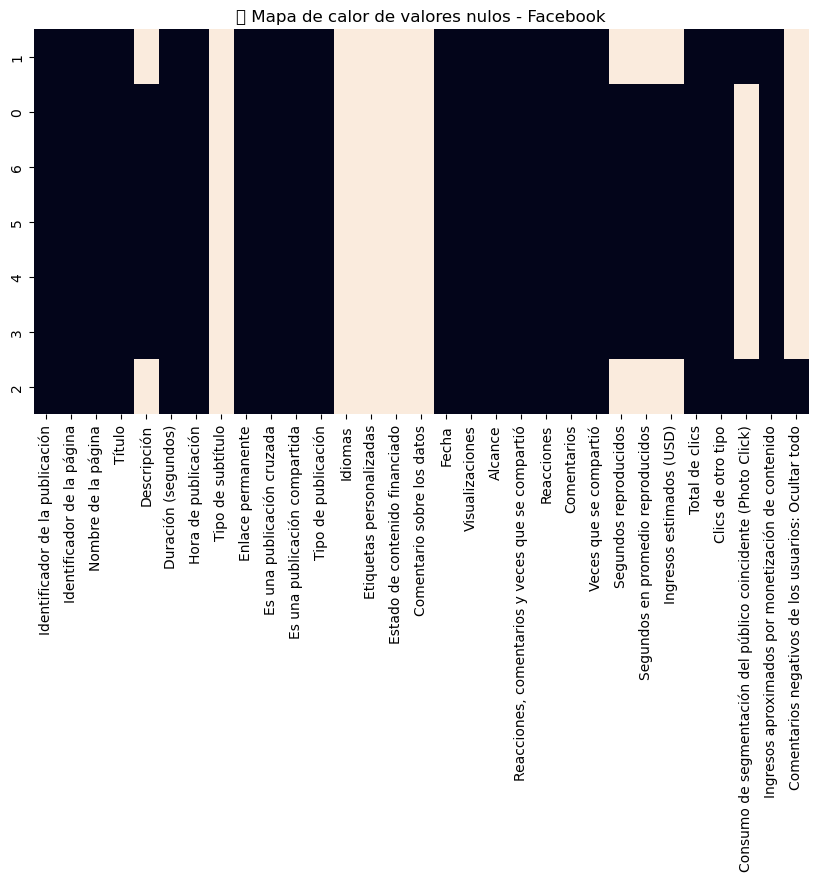

In [26]:
plt.figure(figsize=(10, 5))
sns.heatmap(facebook_df.isnull(), cbar=False)
plt.title('🔍 Mapa de calor de valores nulos - Facebook')
plt.show()


In [13]:
# Lista de todas las columnas que quieres extraer
cols = [
    'Comentarios',
    'Total de clics',
    'Veces que se compartió',
    'Alcance',
    'Reacciones',
    'Reacciones, comentarios y veces que se compartió',
    'Duración (segundos)',
    'Segundos reproducidos',
    'Segundos en promedio reproducidos',
    'Ingresos estimados (USD)',
    'Ingresos aproximados por monetización de contenido',
    'Clics de otro tipo',
    'Clics en el enlace',
    'Consumo de segmentación del público coincidente (Photo Click)'
]

# Filtramos solo las que existen en facebook_df.columns
cols_validas = [c for c in cols if c in facebook_df.columns]

# Extraemos el nuevo DataFrame
data_cuantitativa_facebook = facebook_df[cols_validas].copy()

# Detectamos columnas float64 y las convertimos a Int64 (nullable)
float_cols = data_cuantitativa_facebook.select_dtypes(include='float64').columns
for c in float_cols:
    data_cuantitativa_facebook[c] = (
        data_cuantitativa_facebook[c]
        .round()             # redondea al entero más cercano
        .astype('Int64')     # entero nullable para conservar NaN
    )

# Vista previa
data_cuantitativa_facebook.head()

,Comentarios,Total de clics,Veces que se compartió,Alcance,Reacciones,"Reacciones, comentarios y veces que se compartió",Duración (segundos),Segundos reproducidos,Segundos en promedio reproducidos,Ingresos estimados (USD),Ingresos aproximados por monetización de contenido,Clics de otro tipo,Consumo de segmentación del público coincidente (Photo Click)
1,10,380,25,2587,117,152,0,<NA>,<NA>,<NA>,0,128,252
0,16,70,12,1110,94,122,40,9874,9,0,0,70,<NA>
6,5,28,9,1003,66,80,32,7133,7,0,0,28,<NA>
5,8,14,11,369,41,60,20,2504,6,0,0,14,<NA>
4,18,34,6,635,45,69,24,4281,7,0,0,34,<NA>


In [17]:
# Publicación con más alcance
idx_max_alcance = facebook_df['Alcance'].idxmax()
print("📢 Publicación con más alcance:")
print("Descripción:", facebook_df.loc[idx_max_alcance, 'Título'])#Título Descripción

# Publicación con más comentarios
idx_max_comentarios = facebook_df['Comentarios'].idxmax()
print("\n💬 Publicación con más comentarios:")
print("Descripción:", facebook_df.loc[idx_max_comentarios, 'Descripción'])

# Publicación con más me gusta
idx_max_megusta = facebook_df['Reacciones, comentarios y veces que se compartió'].idxmax()
print("\n❤️ Publicación con más Me gusta:")
print("Descripción:", facebook_df.loc[idx_max_megusta, 'Título'])


📢 Publicación con más alcance:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
EleccionesColombiaYoVotoPorJuan

💬 Publicación con más comentarios:
Descripción: Los territorios cambian cuando hay verdadera representación que gestione recursos y genere transformación real. 🤝

Es momento de mover el tablero y abrir nuevas oportunidades para nuestra gente. ✊

#LaUniónHaceLaFuerza
#JuanCamiloVélez
#SenadoC20
#YoVotoPorJuan

❤️ Publicación con más Me gusta:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multi

In [18]:
# Obtener las 3 publicaciones con menos Me gusta
menos_megusta = facebook_df.nsmallest(3, 'Reacciones, comentarios y veces que se compartió')[['Descripción', 'Reacciones, comentarios y veces que se compartió']]
print("🚨 Publicaciones con menos Reacciones, comentarios y veces que se compartió:")
print(menos_megusta)


🚨 Publicaciones con menos Reacciones, comentarios y veces que se compartió:
                                         Descripción  \
5  Hoy ser conservador también es apostar por una...   
4  Los territorios cambian cuando hay verdadera r...   
6  De principio a fin en esta campaña siempre con...   

   Reacciones, comentarios y veces que se compartió  
5                                                60  
4                                                69  
6                                                80  


In [19]:
# Asegúrate de que los nombres de las columnas coincidan exactamente con tu archivo
# Ejemplo: 'Descripción' y 'Reacciones, comentarios y veces que se compartió'
col_desc = "Descripción"
col_metric = "Comentarios"
col_fecha = "Hora de publicación"

# Convertir la columna métrica a numérica (por si viene como texto con comas)
facebook_df[col_metric] = pd.to_numeric(facebook_df[col_metric].astype(str).str.replace(",", ""), errors="coerce")

# Ordenar el dataframe de mayor a menor por la métrica
df_sorted = facebook_df.sort_values(by=col_metric, ascending=False)

# Obtener la publicación con mayor cantidad de interacciones
top_post = df_sorted.iloc[0]

print("📌 Publicación con mayor cantidad de comentarios:")
print(f"Descripción: {top_post[col_desc]}")
print(f"Total de comentarios: {top_post[col_metric]}")
print(f"Fecha: {top_post[col_fecha]}")
print("\n")

# Mostrar lista completa ordenada
print("📋 Lista de publicaciones ordenadas por comentarios:")
for i, row in df_sorted.iterrows():
    print(f"{row[col_desc]} --> {row[col_metric]} --> {row[col_fecha]}")

📌 Publicación con mayor cantidad de comentarios:
Descripción: Los territorios cambian cuando hay verdadera representación que gestione recursos y genere transformación real. 🤝

Es momento de mover el tablero y abrir nuevas oportunidades para nuestra gente. ✊

#LaUniónHaceLaFuerza
#JuanCamiloVélez
#SenadoC20
#YoVotoPorJuan
Total de comentarios: 18
Fecha: 2026-02-13 09:00:00


📋 Lista de publicaciones ordenadas por comentarios:
Los territorios cambian cuando hay verdadera representación que gestione recursos y genere transformación real. 🤝

Es momento de mover el tablero y abrir nuevas oportunidades para nuestra gente. ✊

#LaUniónHaceLaFuerza
#JuanCamiloVélez
#SenadoC20
#YoVotoPorJuan --> 18 --> 2026-02-13 09:00:00
Este 08 de Marzo, vamos a salir a votar con la familia, con los amigos, con los vecinos,  vamos a hacer historia y a renovar el Congreso para que haya representación de verdad. 🇨🇴

#YoVotoC20 
#PartidoConservador 
#YoVotoPorJuan 
#YoMultiplico 
#LaUniónHaceLaFuerza --> 16 --> 

In [22]:
# Asegúrate de que los nombres de las columnas coincidan exactamente con tu archivo
# Ejemplo: 'Descripción' y 'Reacciones, comentarios y veces que se compartió'
col_desc = "Título" #Titulo Descripción
col_metric = "Reacciones, comentarios y veces que se compartió"

# Convertir la columna métrica a numérica (por si viene como texto con comas)
facebook_df[col_metric] = pd.to_numeric(facebook_df[col_metric].astype(str).str.replace(",", ""), errors="coerce")

# Ordenar el dataframe de mayor a menor por la métrica
df_sorted = facebook_df.sort_values(by=col_metric, ascending=False)

# Obtener la publicación con mayor cantidad de interacciones
top_post = df_sorted.iloc[0]

print("📌 Publicación con mayor cantidad de interacciones:")
print(f"Descripción: {top_post[col_desc]}")
print(f"Total interacciones: {top_post[col_metric]}")
print("\n")

# Mostrar lista completa ordenada
print("📋 Lista de publicaciones ordenadas por interacciones:")
for i, row in df_sorted.iterrows():
    print(f"{row[col_desc]} --> {row[col_metric]}")

📌 Publicación con mayor cantidad de interacciones:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
EleccionesColombiaYoVotoPorJuan
Total interacciones: 152


📋 Lista de publicaciones ordenadas por interacciones:
Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
EleccionesColombiaYoVotoPorJu

In [23]:
data_cuantitativa_facebook.describe()

,Comentarios,Total de clics,Veces que se compartió,Alcance,Reacciones,"Reacciones, comentarios y veces que se compartió",Duración (segundos),Segundos reproducidos,Segundos en promedio reproducidos,Ingresos estimados (USD),Ingresos aproximados por monetización de contenido,Clics de otro tipo,Consumo de segmentación del público coincidente (Photo Click)
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,5.0,5.0,5.0,7.0,7.000000,2.0
mean,11.000000,115.142857,13.571429,1242.142857,74.857143,99.428571,22.285714,5771.0,7.2,0.0,0.0,56.000000,207.0
std,4.654747,145.276092,6.294366,850.722522,28.678846,33.773052,16.948100,2832.150508,1.095445,0.0,0.0,43.726422,63.63961
min,5.000000,14.000000,6.000000,369.000000,41.000000,60.000000,0.000000,2504.0,6.0,0.0,0.0,14.000000,162.0
25%,8.000000,24.000000,10.000000,678.000000,54.000000,74.500000,10.000000,4281.0,7.0,0.0,0.0,24.000000,184.5
50%,10.000000,34.000000,12.000000,1003.000000,66.000000,89.000000,24.000000,5063.0,7.0,0.0,0.0,34.000000,207.0
75%,14.000000,165.000000,16.000000,1690.000000,96.000000,123.000000,36.000000,7133.0,7.0,0.0,0.0,84.000000,229.5
max,18.000000,380.000000,25.000000,2587.000000,117.000000,152.000000,40.000000,9874.0,9.0,0.0,0.0,128.000000,252.0


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


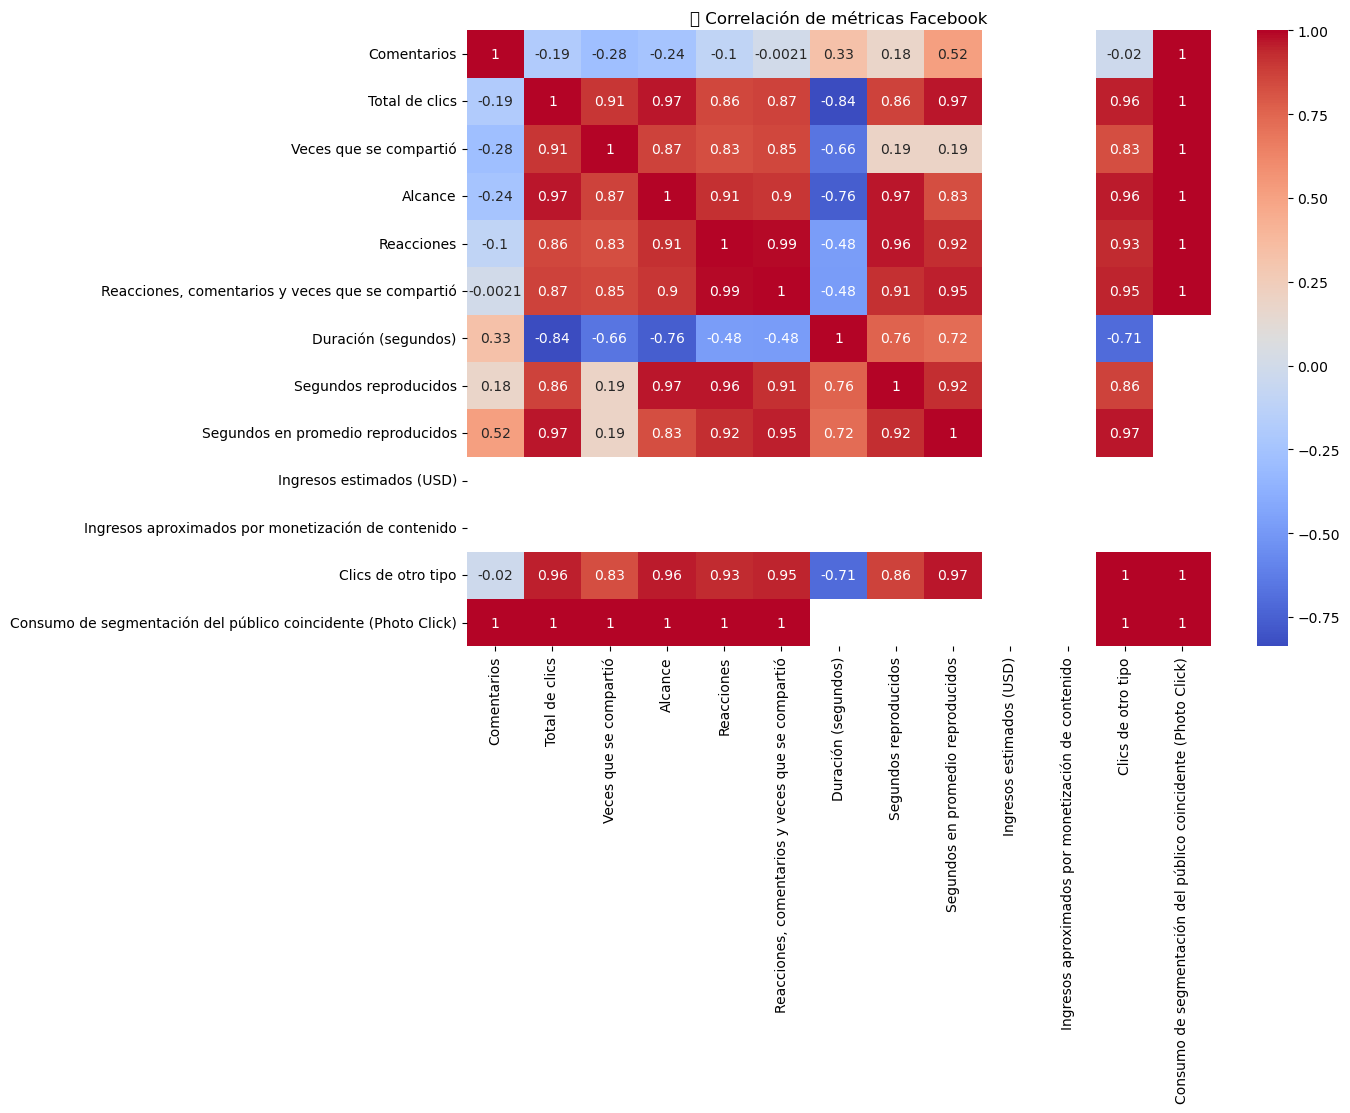

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_cuantitativa_facebook.corr(), annot=True, cmap='coolwarm')
plt.title('📈 Correlación de métricas Facebook')
plt.show()

In [27]:
# 1) Convierte a datetime
facebook_df['Hora de publicación'] = pd.to_datetime(
    facebook_df['Hora de publicación'],
    errors='coerce'
)

# 2) Crea data_linea_tiempo_facebook a partir de facebook_df ya ordenado
data_linea_tiempo_facebook = facebook_df.sort_values('Hora de publicación').copy()

# 3) Interpola sólo las columnas numéricas
numeric_cols = data_linea_tiempo_facebook.select_dtypes(include='number').columns
data_linea_tiempo_facebook[numeric_cols] = (
    data_linea_tiempo_facebook[numeric_cols]
    .interpolate()  # por defecto interpolación lineal
)

# 4) Selecciona las columnas que quieres en la serie de tiempo
cols_linea = [
    'Hora de publicación',
    'Total de clics',
    'Veces que se compartió',
    'Comentarios',
    'Reacciones',
]
if 'Reacciones, comentarios y veces que se compartió' in facebook_df.columns:
    cols_linea.append('Reacciones, comentarios y veces que se compartió')

data_linea_tiempo_facebook = data_linea_tiempo_facebook[cols_linea]

# 5) (Opcional) Un segundo .interpolate() no es necesario aquí,
#    pues ya lo hicimos en el paso 3. Y así evitas tocar la columna datetime.

# Vista previa
data_linea_tiempo_facebook.head()


,Hora de publicación,Total de clics,Veces que se compartió,Comentarios,Reacciones,"Reacciones, comentarios y veces que se compartió"
1,2026-02-09 09:28:00,380,25,10,117,152
0,2026-02-10 17:24:00,70,12,16,94,122
6,2026-02-11 09:10:00,28,9,5,66,80
5,2026-02-12 09:00:00,14,11,8,41,60
4,2026-02-13 09:00:00,34,6,18,45,69


C:\Users\57317\AppData\Local\Temp\ipykernel_37340\1786053902.py:12: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


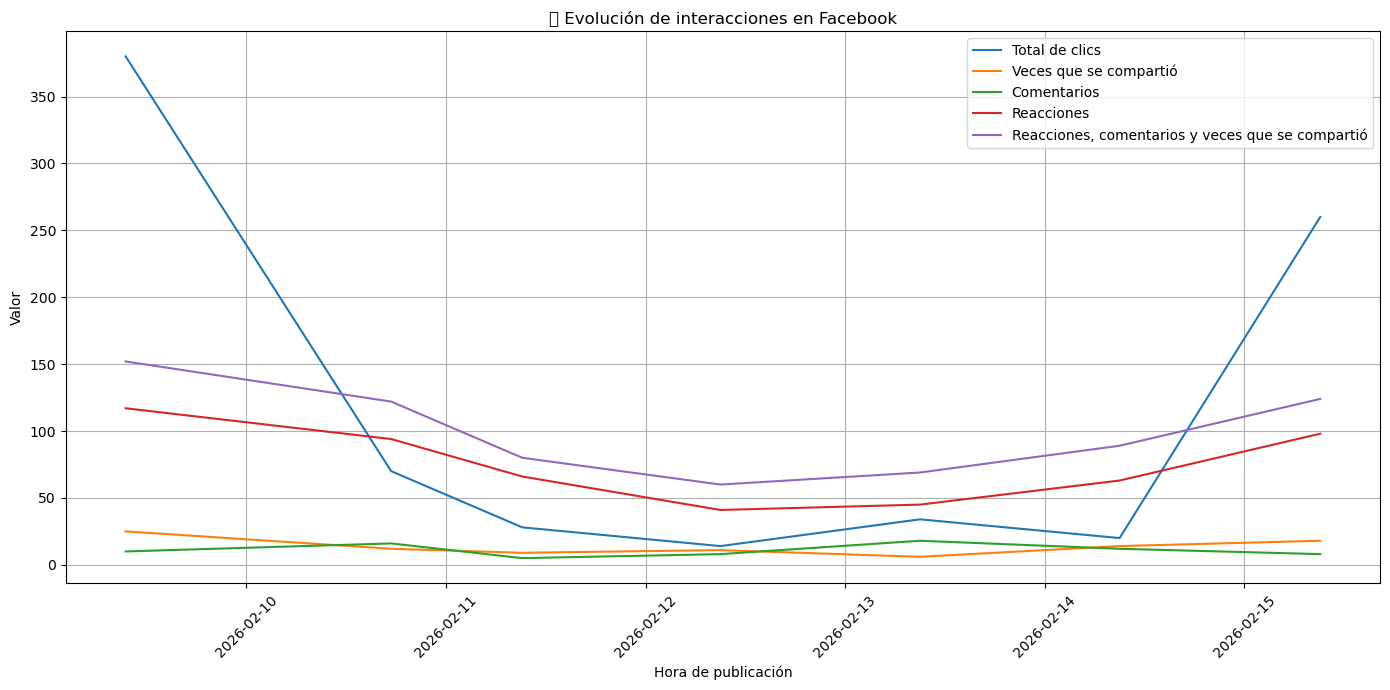

In [28]:
plt.figure(figsize=(14, 7))

for col in data_linea_tiempo_facebook.columns[1:]:
    plt.plot(data_linea_tiempo_facebook['Hora de publicación'], data_linea_tiempo_facebook[col], label=col)

plt.xlabel('Hora de publicación')
plt.ylabel('Valor')
plt.title('📆 Evolución de interacciones en Facebook')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


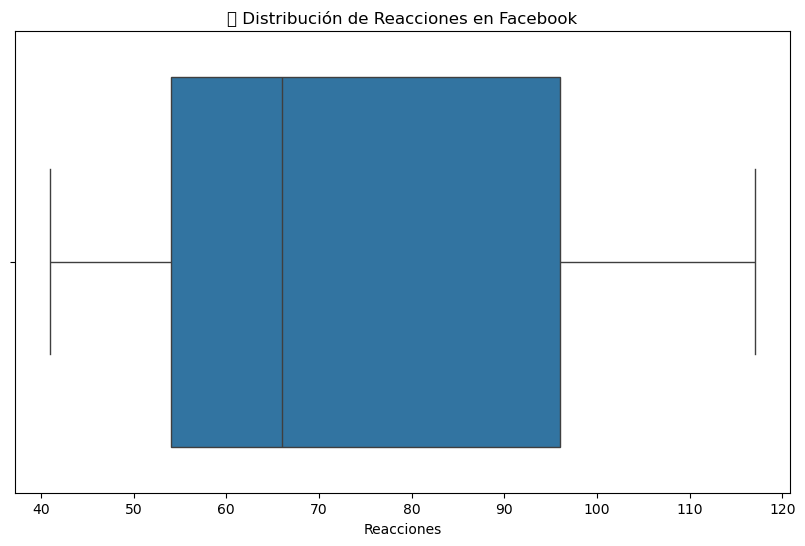

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=facebook_df['Reacciones'])
plt.title('📦 Distribución de Reacciones en Facebook')
plt.show()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


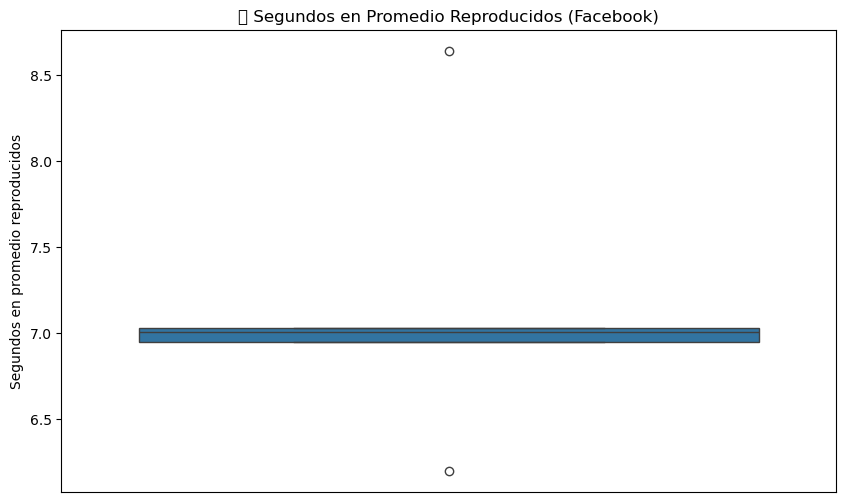

In [30]:
# Extraemos la serie y eliminamos NaN
data_fb = facebook_df['Segundos en promedio reproducidos'].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(y=data_fb)
plt.title('⏱ Segundos en Promedio Reproducidos (Facebook)')
plt.ylabel('Segundos en promedio reproducidos')
plt.xticks([])  # opcional: oculta la etiqueta del eje x
plt.show()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


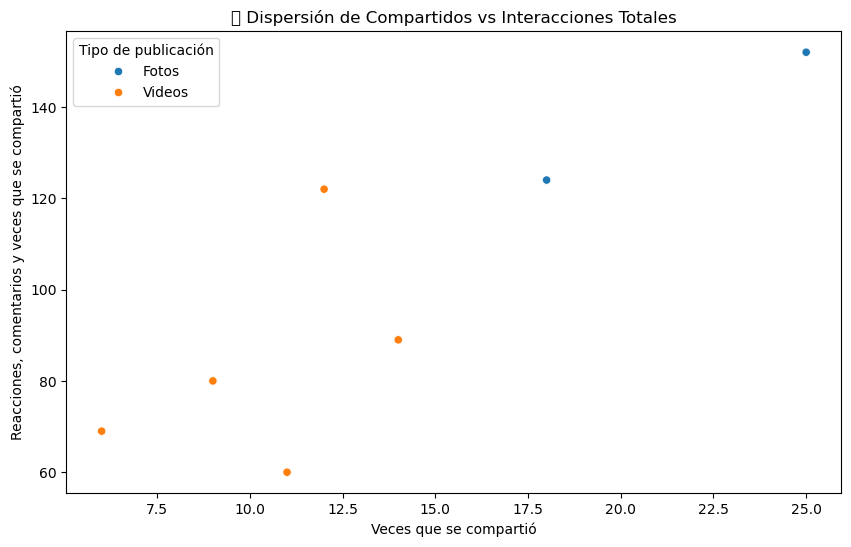

In [31]:
if 'Reacciones, comentarios y veces que se compartió' in facebook_df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=facebook_df, x='Veces que se compartió',
                    y='Reacciones, comentarios y veces que se compartió',
                    hue='Tipo de publicación')
    plt.title('📍 Dispersión de Compartidos vs Interacciones Totales')
    plt.show()


In [32]:
# Asegurar que no haya espacios en los nombres de columnas
instagram_df.columns = instagram_df.columns.str.strip()

# Revisar la estructura de los datos
instagram_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 1 to 2
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Identificador de la publicación  9 non-null      int64         
 1   Identificador de la cuenta       9 non-null      int64         
 2   Nombre de usuario de la cuenta   9 non-null      object        
 3   Nombre de la cuenta              9 non-null      object        
 4   Descripción                      9 non-null      object        
 5   Duración (segundos)              9 non-null      int64         
 6   Hora de publicación              9 non-null      datetime64[ns]
 7   Enlace permanente                9 non-null      object        
 8   Tipo de publicación              9 non-null      object        
 9   Comentario sobre los datos       0 non-null      float64       
 10  Fecha                            9 non-null      object        
 11  Vi

In [33]:
# 1) Definimos la lista de columnas que pretendemos extraer
cols_ig = [
    'Comentarios',
    'Alcance',
    'Me gusta',
    'Veces que se compartió',
    'Veces que se guardó',
    'Duración (segundos)',
    'Visualizaciones'
]

# 2) Filtramos sólo las que realmente existen
cols_ig_validas = [c for c in cols_ig if c in instagram_df.columns]

# 3) Creamos el DataFrame
data_cuantitativa_instagram = instagram_df[cols_ig_validas].copy()

# 4) Convertimos floats a enteros nullable
float_cols_ig = data_cuantitativa_instagram.select_dtypes(include='float64').columns
for c in float_cols_ig:
    data_cuantitativa_instagram[c] = (
        data_cuantitativa_instagram[c]
        .round()            # redondea al entero más cercano
        .astype('Int64')    # usa Int64 para conservar NaN
    )

# 5) Vista previa
data_cuantitativa_instagram.head()


,Comentarios,Alcance,Me gusta,Veces que se compartió,Veces que se guardó,Duración (segundos),Visualizaciones
1,11,2155,186,14,0,0,11805
0,1,795,63,0,0,39,1195
8,2,719,35,0,2,31,1089
7,2,1114,75,3,1,19,1632
6,2,861,69,2,0,23,1349


In [34]:
data_cuantitativa_instagram.describe()

,Comentarios,Alcance,Me gusta,Veces que se compartió,Veces que se guardó,Duración (segundos),Visualizaciones
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,2.777778,1074.333333,78.222222,3.777778,0.555556,16.888889,3109.777778
std,3.113590,516.170272,46.596078,4.737557,0.726483,17.338140,3435.729827
min,1.000000,638.000000,31.000000,0.000000,0.000000,0.000000,909.000000
25%,2.000000,789.000000,54.000000,1.000000,0.000000,0.000000,1195.000000
50%,2.000000,861.000000,69.000000,2.000000,0.000000,19.000000,1632.000000
75%,2.000000,1114.000000,87.000000,4.000000,1.000000,31.000000,3053.000000
max,11.000000,2155.000000,186.000000,14.000000,2.000000,40.000000,11805.000000


In [35]:
# Asegúrate de que los nombres de las columnas coincidan exactamente con tu archivo
# Ejemplo: 'Descripción' y 'Reacciones, comentarios y veces que se compartió'
col_desc = "Descripción"
col_metric = "Comentarios"
col_fecha = "Hora de publicación"

# Convertir la columna métrica a numérica (por si viene como texto con comas)
instagram_df[col_metric] = pd.to_numeric(instagram_df[col_metric].astype(str).str.replace(",", ""), errors="coerce")

# Ordenar el dataframe de mayor a menor por la métrica
df_sorted = instagram_df.sort_values(by=col_metric, ascending=False)

# Obtener la publicación con mayor cantidad de interacciones
top_post = df_sorted.iloc[0]

print("📌 Publicación con mayor cantidad de comentarios:")
print(f"Descripción: {top_post[col_desc]}")
print(f"Total de comentarios: {top_post[col_metric]}")
print(f"Fecha: {top_post[col_fecha]}")
print("\n")

# Mostrar lista completa ordenada
print("📋 Lista de publicaciones ordenadas por comentarios:")
for i, row in df_sorted.iterrows():
    print(f"{row[col_desc]} --> {row[col_metric]} --> {row[col_fecha]}")

📌 Publicación con mayor cantidad de comentarios:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan
Total de comentarios: 11
Fecha: 2026-02-09 09:28:00


📋 Lista de publicaciones ordenadas por comentarios:
Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#Elec

c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


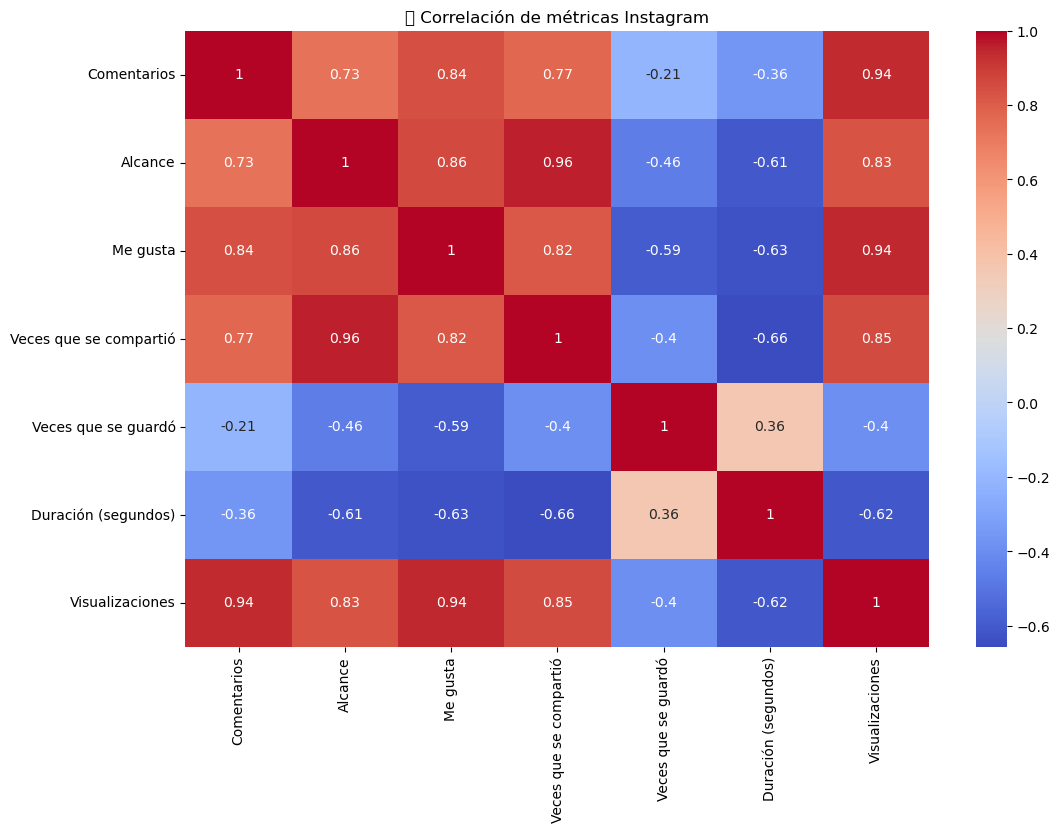

In [36]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_cuantitativa_instagram.corr(), annot=True, cmap='coolwarm')
plt.title('📈 Correlación de métricas Instagram')
plt.show()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


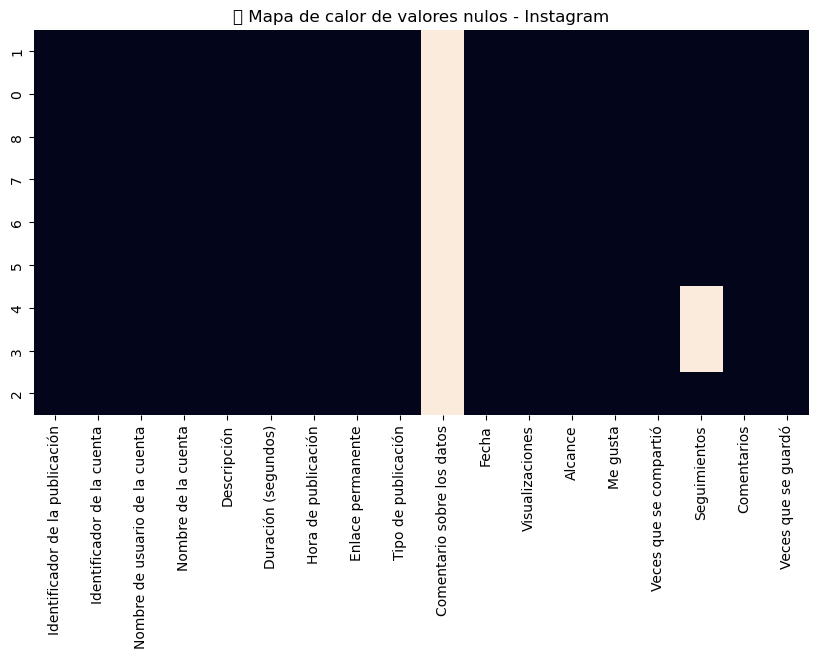

In [37]:
plt.figure(figsize=(10, 5))
sns.heatmap(instagram_df.isnull(), cbar=False)
plt.title('🔍 Mapa de calor de valores nulos - Instagram')
plt.show()


In [38]:
instagram_df['Hora de publicación'] = pd.to_datetime(instagram_df['Hora de publicación'], errors='coerce')

data_linea_tiempo_instagram = instagram_df.sort_values('Hora de publicación')

cols_linea_insta = ['Hora de publicación', 'Alcance', 'Visualizaciones', 'Me gusta', 'Veces que se compartió', 'Veces que se guardó', 'Comentarios']
data_linea_tiempo_instagram = data_linea_tiempo_instagram[cols_linea_insta]

data_linea_tiempo_instagram.interpolate(inplace=True)

data_linea_tiempo_instagram.head()


,Hora de publicación,Alcance,Visualizaciones,Me gusta,Veces que se compartió,Veces que se guardó,Comentarios
1,2026-02-09 09:28:00,2155,11805,186,14,0,11
0,2026-02-10 17:24:00,795,1195,63,0,0,1
8,2026-02-11 09:10:00,719,1089,35,0,2,2
7,2026-02-12 09:00:00,1114,1632,75,3,1,2
6,2026-02-13 09:00:00,861,1349,69,2,0,2


C:\Users\57317\AppData\Local\Temp\ipykernel_37340\2384993977.py:12: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


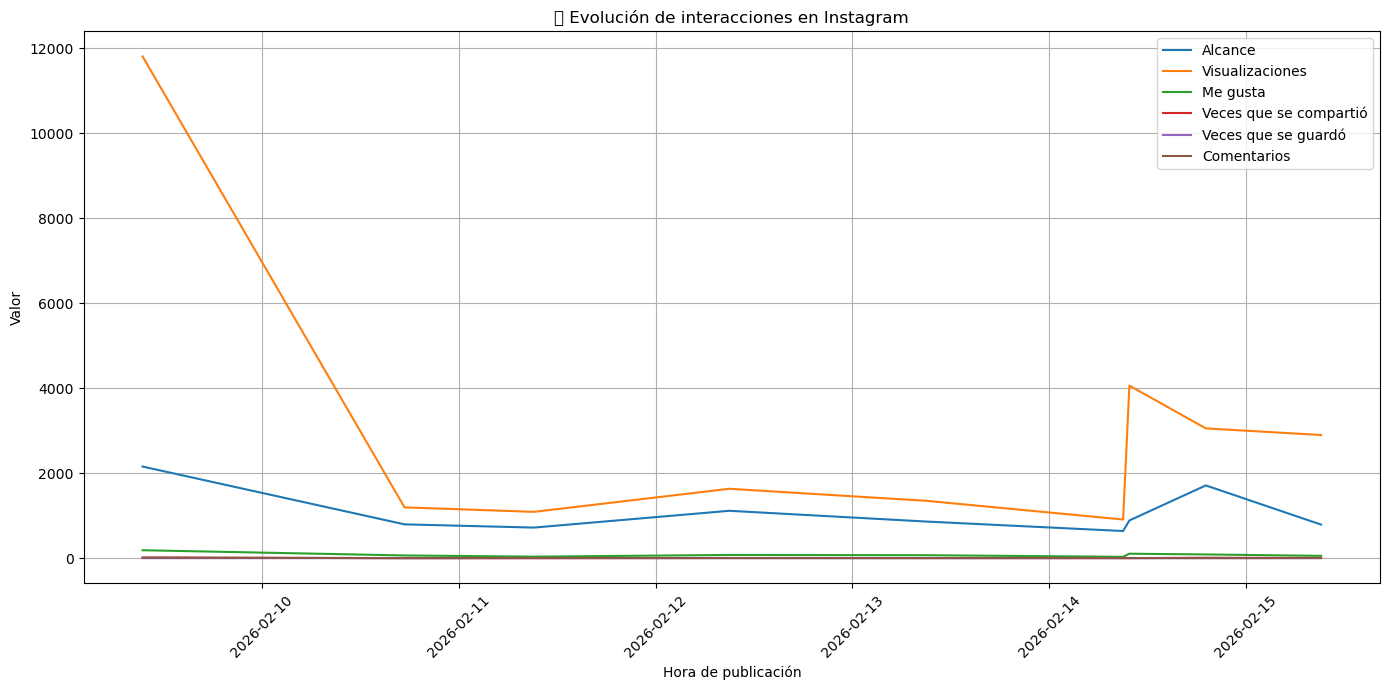

In [39]:
plt.figure(figsize=(14, 7))

for col in data_linea_tiempo_instagram.columns[1:]:
    plt.plot(data_linea_tiempo_instagram['Hora de publicación'], data_linea_tiempo_instagram[col], label=col)

plt.xlabel('Hora de publicación')
plt.ylabel('Valor')
plt.title('📆 Evolución de interacciones en Instagram')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


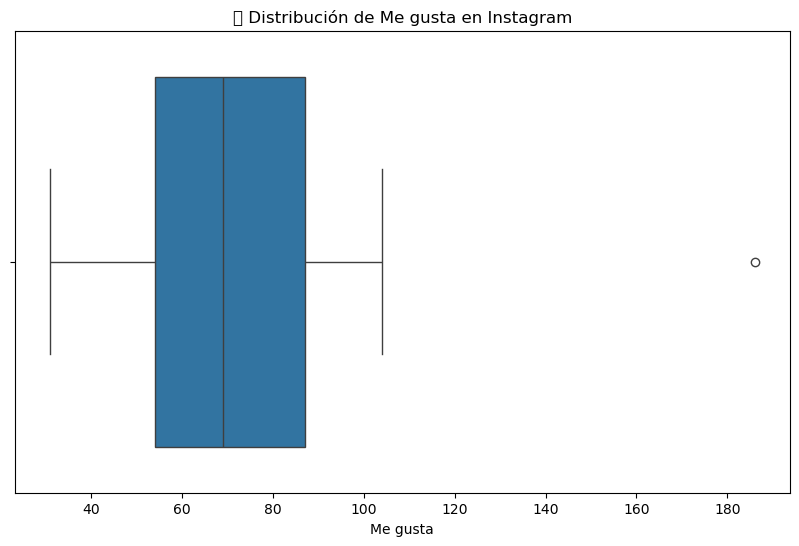

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=instagram_df['Me gusta'])
plt.title('📦 Distribución de Me gusta en Instagram')
plt.show()


In [41]:
# Publicación con más alcance
idx_max_alcance = instagram_df['Alcance'].idxmax()
print("📢 Publicación con más alcance:")
print("Descripción:", instagram_df.loc[idx_max_alcance, 'Descripción'])

# Publicación con más comentarios
idx_max_comentarios = instagram_df['Comentarios'].idxmax()
print("\n💬 Publicación con más comentarios:")
print("Descripción:", instagram_df.loc[idx_max_comentarios, 'Descripción'])

# Publicación con más me gusta
idx_max_megusta = instagram_df['Me gusta'].idxmax()
print("\n❤️ Publicación con más Me gusta:")
print("Descripción:", instagram_df.loc[idx_max_megusta, 'Descripción'])


📢 Publicación con más alcance:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan

💬 Publicación con más comentarios:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan

❤️ Publicación con más Me gusta:
Descripción: 

In [42]:
# Obtener las 3 publicaciones con menos Me gusta
menos_megusta = instagram_df.nsmallest(3, 'Me gusta')[['Descripción', 'Me gusta']]
print("🚨 Publicaciones con menos Me gusta:")
print(menos_megusta)


🚨 Publicaciones con menos Me gusta:
                                         Descripción  Me gusta
5  En ningún otro partido hubieran permitido que ...        31
8  De principio a fin en esta campaña siempre con...        35
2  Este proceso más que de política.\nSe trata de...        54


In [43]:
# Asegúrate de que los nombres de las columnas coincidan exactamente con tu archivo
# Ejemplo: 'Descripción' y 'Reacciones, comentarios y veces que se compartió'
col_desc = "Descripción"
col_metric = "Me gusta"

# Convertir la columna métrica a numérica (por si viene como texto con comas)
instagram_df[col_metric] = pd.to_numeric(instagram_df[col_metric].astype(str).str.replace(",", ""), errors="coerce")

# Ordenar el dataframe de mayor a menor por la métrica
df_sorted_insta = instagram_df.sort_values(by=col_metric, ascending=False)

# Obtener la publicación con mayor cantidad de interacciones
top_post = df_sorted_insta.iloc[0]

print("📌 Publicación con mayor cantidad de Me gustas:")
print(f"Descripción: {top_post[col_desc]}")
print(f"Total Me gustas: {top_post[col_metric]}")
print("\n")

# Mostrar lista completa ordenada
print("📋 Lista de publicaciones ordenadas por Me gustas:")
for i, row in df_sorted_insta.iterrows():
    print(f"{row[col_desc]} --> {row[col_metric]}")

📌 Publicación con mayor cantidad de Me gustas:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan
Total Me gustas: 186


📋 Lista de publicaciones ordenadas por Me gustas:
Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan --> 186

In [44]:
# Asegúrate de que los nombres de las columnas coincidan exactamente con tu archivo
# Ejemplo: 'Descripción' y 'Reacciones, comentarios y veces que se compartió'
col_desc = "Descripción"
col_metric = "Comentarios"

# Convertir la columna métrica a numérica (por si viene como texto con comas)
instagram_df[col_metric] = pd.to_numeric(instagram_df[col_metric].astype(str).str.replace(",", ""), errors="coerce")

# Ordenar el dataframe de mayor a menor por la métrica
df_sorted_insta = instagram_df.sort_values(by=col_metric, ascending=False)

# Obtener la publicación con mayor cantidad de interacciones
top_post = df_sorted_insta.iloc[0]

print("📌 Publicación con mayor cantidad de Comentarios:")
print(f"Descripción: {top_post[col_desc]}")
print(f"Total Comentarios: {top_post[col_metric]}")
print("\n")

# Mostrar lista completa ordenada
print("📋 Lista de publicaciones ordenadas por Comentarios:")
for i, row in df_sorted_insta.iterrows():
    print(f"{row[col_desc]} --> {row[col_metric]}")

📌 Publicación con mayor cantidad de Comentarios:
Descripción: Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan
Total Comentarios: 11


📋 Lista de publicaciones ordenadas por Comentarios:
Faltan 19 días y este proyecto no se construyó solo: se construyó con trabajo, territorio y gente que cree.
Hoy no basta con reconocer el esfuerzo, hoy necesitamos multiplicarlo.
Habla, comparte, convence, suma.
Porque cuando la convicción es real, el voto se multiplica.
La unión hace la fuerza. Llegamos juntos. 🫶🏼💙

#C20PartidoConservador
#EsHoraDeMultiplicar
#Elecciones8deMarzo
#JuanAlSenado
#EleccionesColombiaYoVotoPorJuan --

In [45]:
# Creamos un nuevo DataFrame con columnas equivalentes
fb_common = facebook_df[['Hora de publicación', 'Alcance', 'Comentarios', 'Veces que se compartió', 'Reacciones']]
fb_common = fb_common.rename(columns={'Reacciones': 'Me gusta'})  # Para comparar con Instagram
fb_common['Plataforma'] = 'Facebook'

ig_common = instagram_df[['Hora de publicación', 'Alcance', 'Comentarios', 'Veces que se compartió', 'Me gusta']]
ig_common['Plataforma'] = 'Instagram'

# Unir ambos DataFrames
comparativo_df = pd.concat([fb_common, ig_common], ignore_index=True)

# Asegurar que 'Hora de publicación' sea datetime
comparativo_df['Hora de publicación'] = pd.to_datetime(comparativo_df['Hora de publicación'], errors='coerce')

# Verificar estructura
comparativo_df.head()


C:\Users\57317\AppData\Local\Temp\ipykernel_37340\3250732562.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ig_common['Plataforma'] = 'Instagram'


,Hora de publicación,Alcance,Comentarios,Veces que se compartió,Me gusta,Plataforma
0,2026-02-09 09:28:00,2587,10,25,117,Facebook
1,2026-02-10 17:24:00,1110,16,12,94,Facebook
2,2026-02-11 09:10:00,1003,5,9,66,Facebook
3,2026-02-12 09:00:00,369,8,11,41,Facebook
4,2026-02-13 09:00:00,635,18,6,45,Facebook


In [46]:
comparativo_df.groupby('Plataforma').mean(numeric_only=True)


,Alcance,Comentarios,Veces que se compartió,Me gusta
Plataforma,,,,
Facebook,1242.142857,11.000000,13.571429,74.857143
Instagram,1074.333333,2.777778,3.777778,78.222222


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


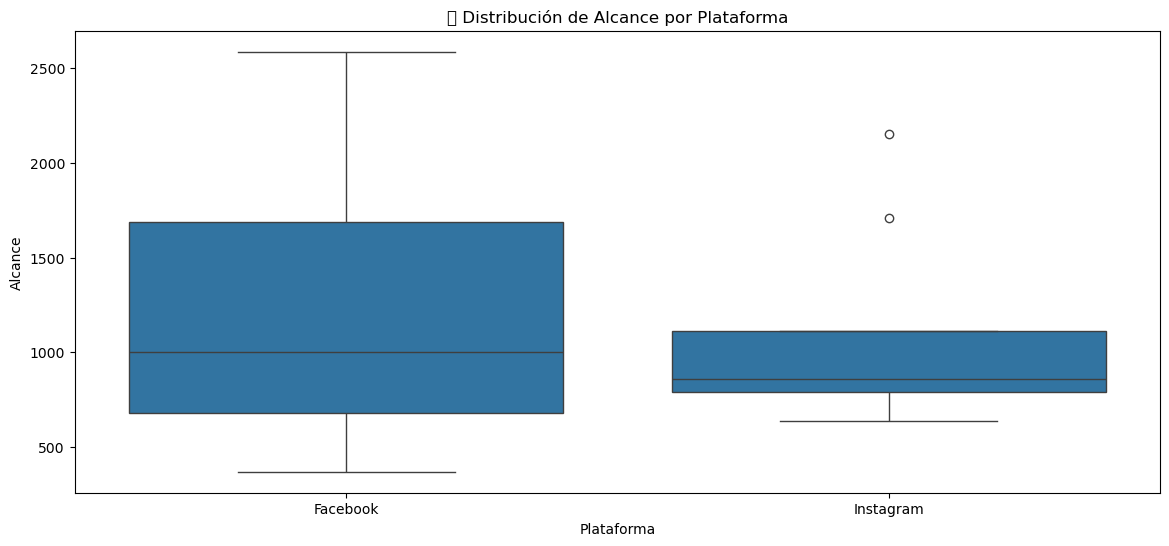

c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


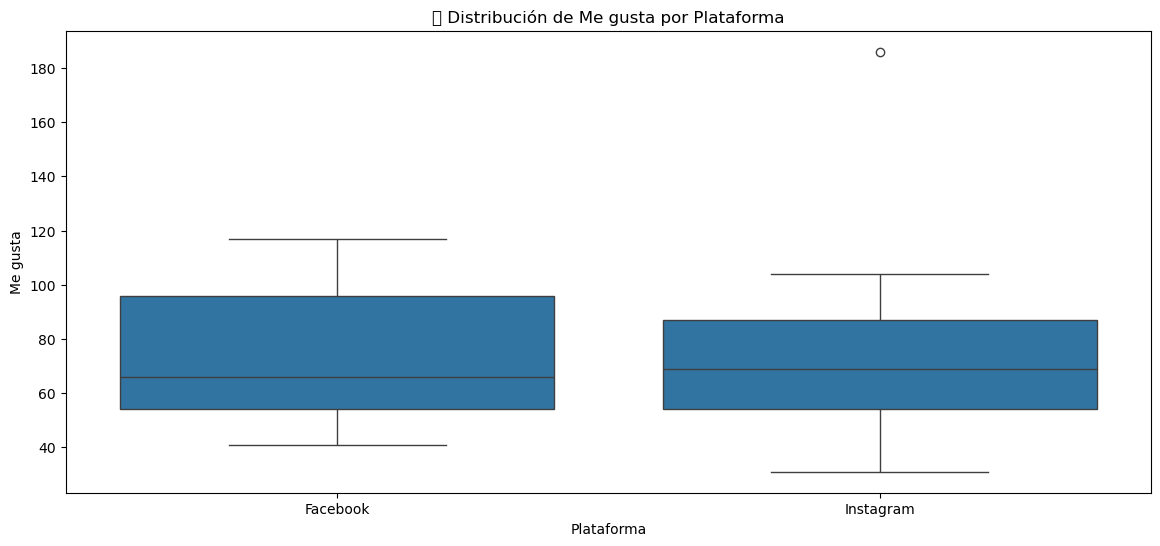

c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


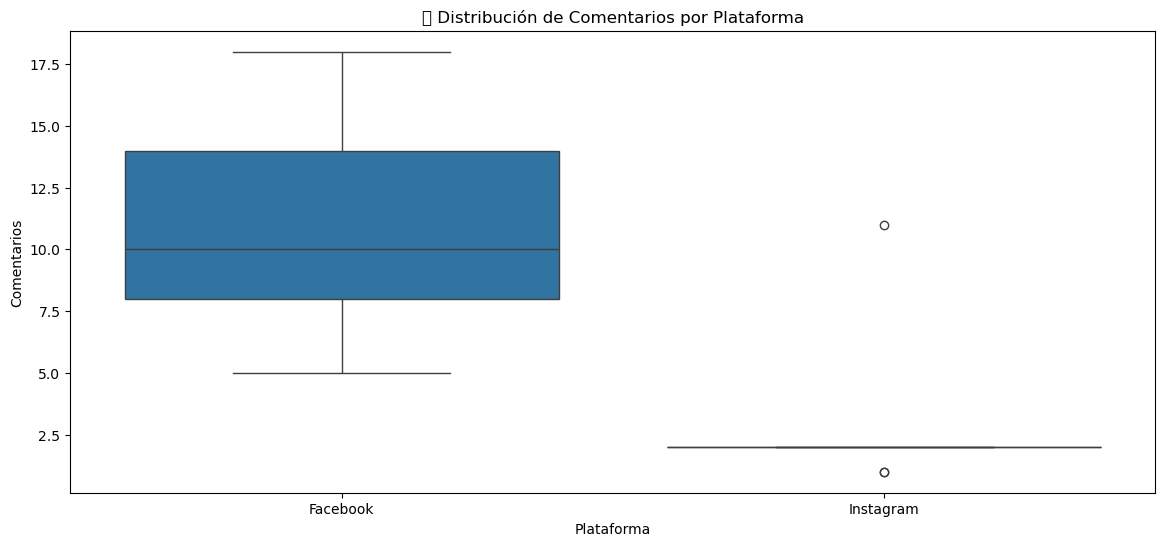

In [47]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=comparativo_df, x='Plataforma', y='Alcance')
plt.title('📦 Distribución de Alcance por Plataforma')
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=comparativo_df, x='Plataforma', y='Me gusta')
plt.title('📦 Distribución de Me gusta por Plataforma')
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=comparativo_df, x='Plataforma', y='Comentarios')
plt.title('📦 Distribución de Comentarios por Plataforma')
plt.show()


C:\Users\57317\AppData\Local\Temp\ipykernel_37340\1123787459.py:6: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


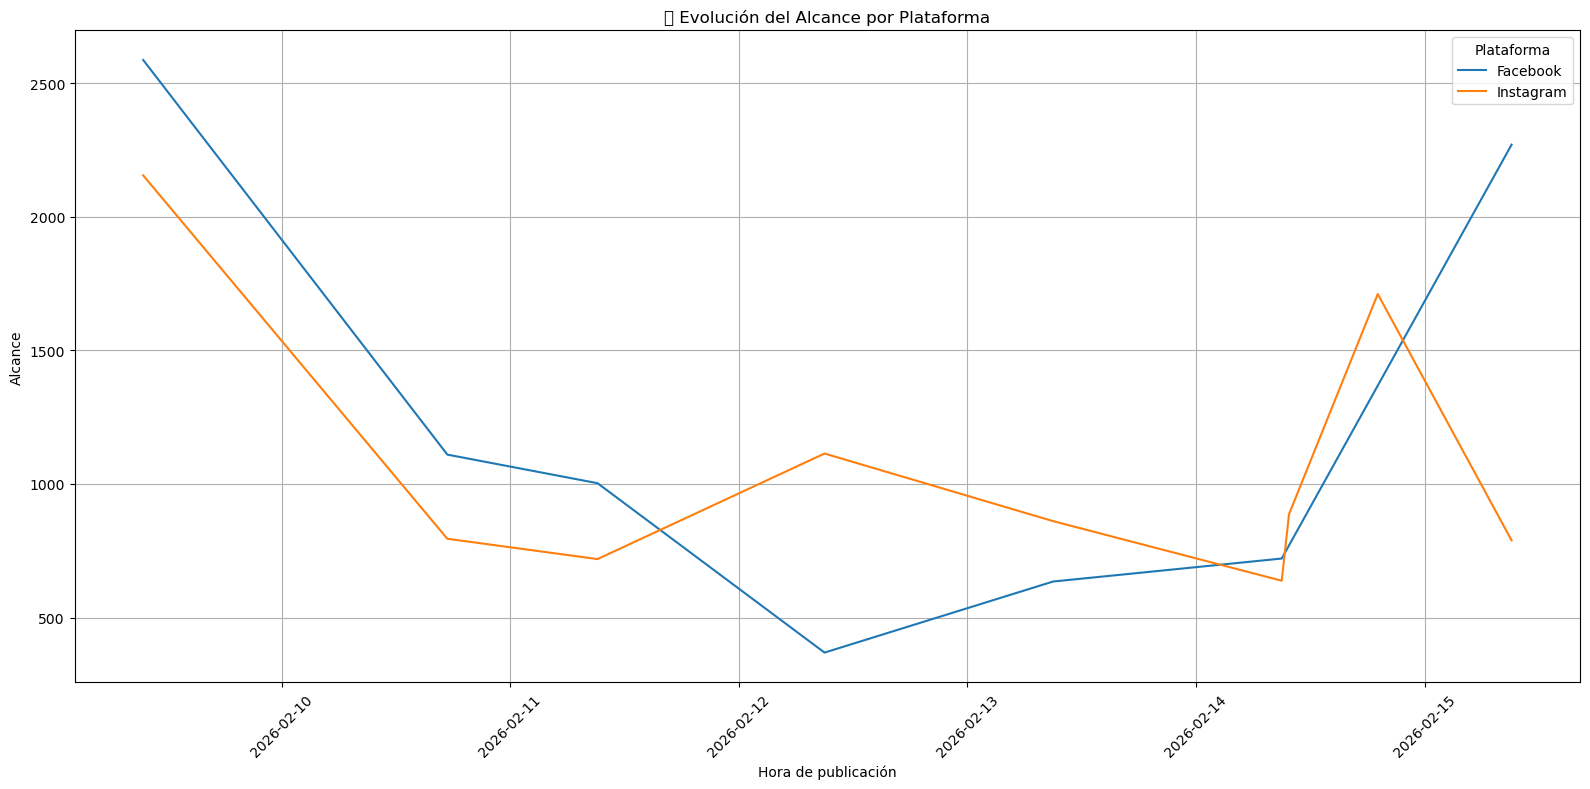

In [48]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=comparativo_df, x='Hora de publicación', y='Alcance', hue='Plataforma')
plt.title('📊 Evolución del Alcance por Plataforma')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


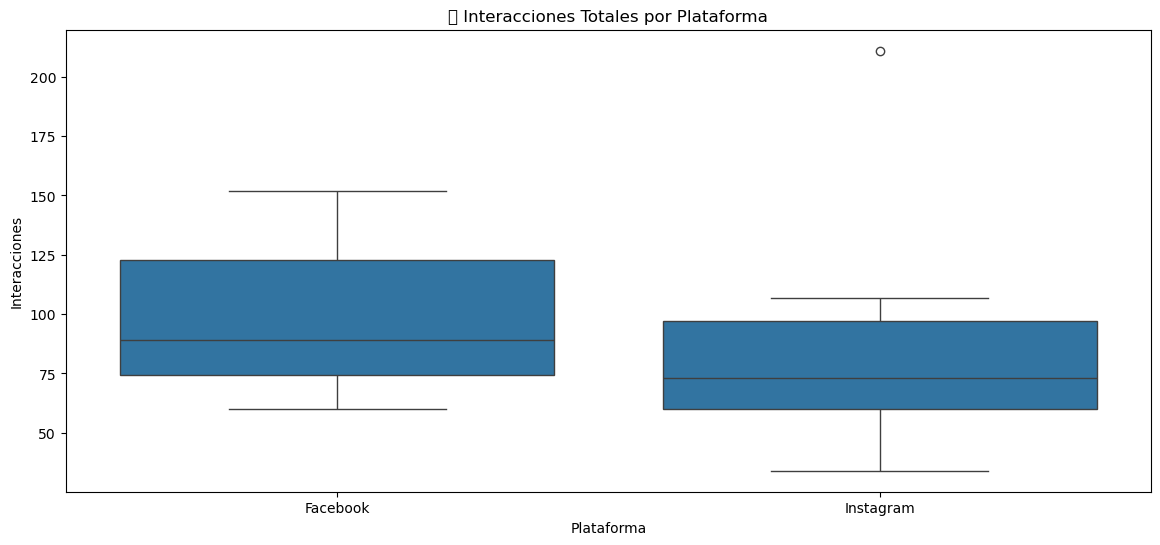

Plataforma
Facebook     99.428571
Instagram    84.777778
Name: Interacciones, dtype: float64

In [49]:
comparativo_df['Interacciones'] = comparativo_df['Me gusta'] + comparativo_df['Comentarios'] + comparativo_df['Veces que se compartió']

plt.figure(figsize=(14, 6))
sns.boxplot(data=comparativo_df, x='Plataforma', y='Interacciones')
plt.title('📦 Interacciones Totales por Plataforma')
plt.show()

# Promedio de interacciones
comparativo_df.groupby('Plataforma')['Interacciones'].mean()

In [50]:
# Calcular estadísticas básicas
stats = comparativo_df.groupby('Plataforma')['Interacciones'] \
                      .agg(['mean','median','std','count']) \
                      .rename(columns={
                          'mean': 'Promedio',
                          'median': 'Mediana',
                          'std': 'Desv. estándar',
                          'count': 'N° de publicaciones'
                      })

print(stats.to_string())



             Promedio  Mediana  Desv. estándar  N° de publicaciones
Plataforma                                                         
Facebook    99.428571     89.0       33.773052                    7
Instagram   84.777778     73.0       53.201921                    9


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


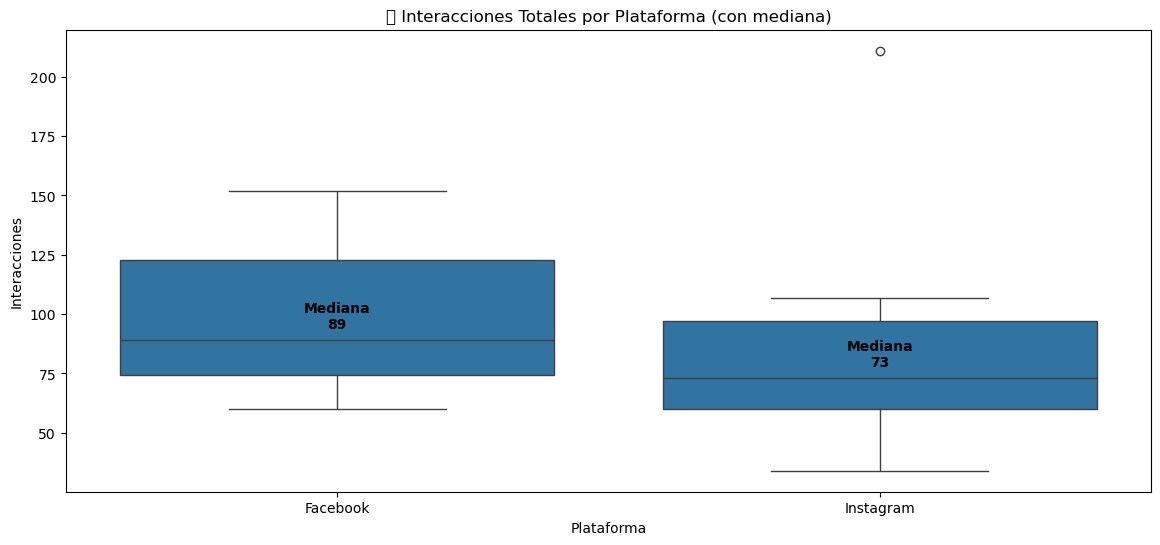

In [51]:
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=comparativo_df, x='Plataforma', y='Interacciones')

# Añadir mediana como texto sobre cada caja
medias = comparativo_df.groupby('Plataforma')['Interacciones'].median()
for i, plat in enumerate(medias.index):
    ax.text(i, medias[plat] + 5, f"Mediana\n{medias[plat]:.0f}", 
            ha='center', fontweight='bold')

plt.title('📦 Interacciones Totales por Plataforma (con mediana)')
plt.show()


In [52]:
# Load the dataset
df_stories = df_stories

# Convert date and time
df_stories["Hora de publicación"] = pd.to_datetime(df_stories["Hora de publicación"], format="%m/%d/%Y %H:%M")
df_stories["Fecha"] = df_stories["Hora de publicación"].dt.date
df_stories["Hora"] = df_stories["Hora de publicación"].dt.hour

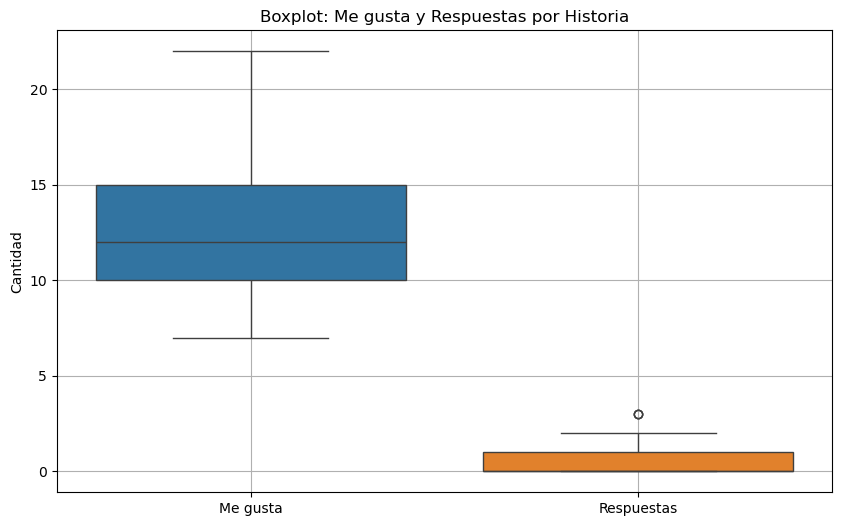

In [53]:
# --- Boxplot: Me gusta y Respuestas ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_stories[["Me gusta", "Respuestas"]])
plt.title("Boxplot: Me gusta y Respuestas por Historia")
plt.ylabel("Cantidad")
plt.grid(True)
plt.show()

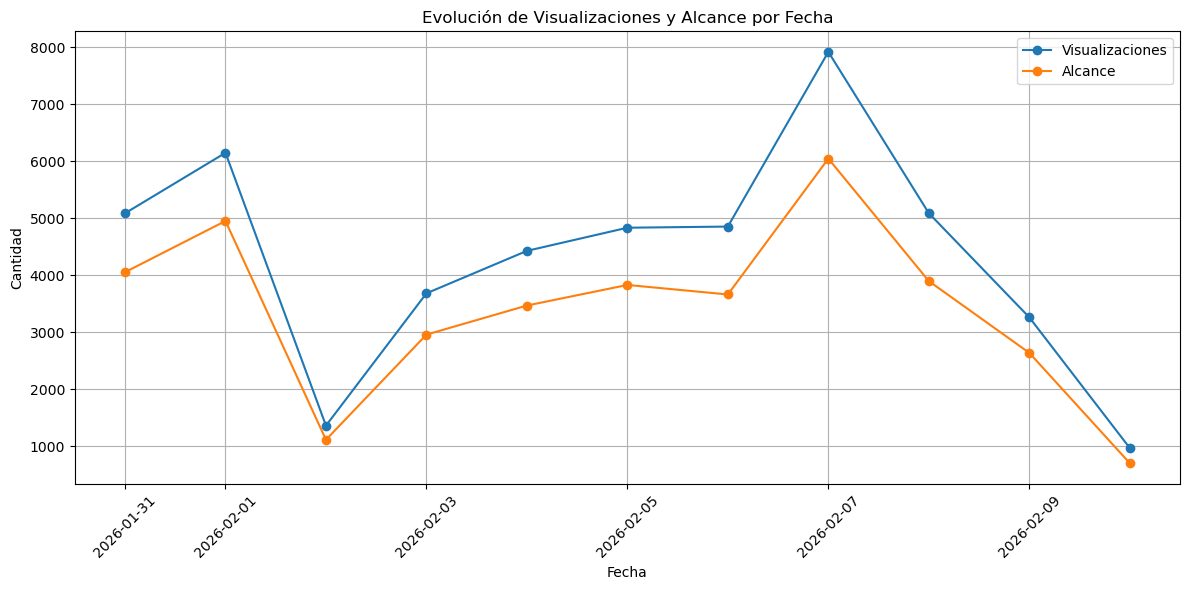

In [41]:
# --- Línea de tiempo: Visualizaciones y Alcance por fecha ---
df_daily = df_stories.groupby("Fecha")[["Visualizaciones", "Alcance"]].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(df_daily["Fecha"], df_daily["Visualizaciones"], label="Visualizaciones", marker='o')
plt.plot(df_daily["Fecha"], df_daily["Alcance"], label="Alcance", marker='o')
plt.title("Evolución de Visualizaciones y Alcance por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

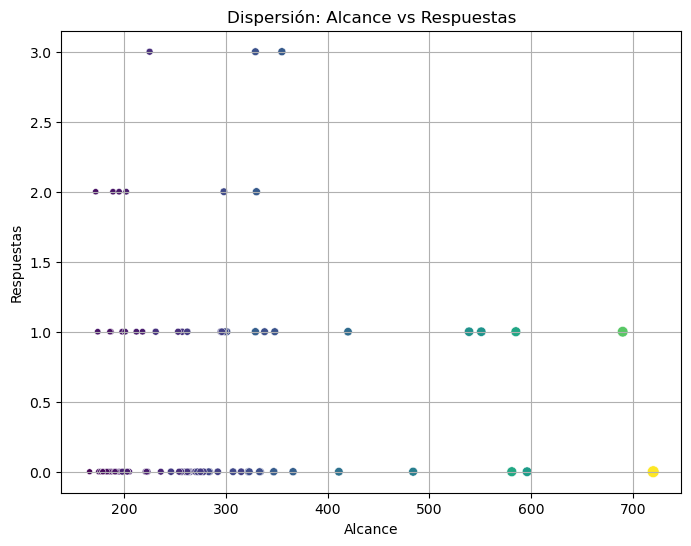

In [54]:
# --- Dispersión: Alcance vs Respuestas ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_stories, x="Alcance", y="Respuestas", size="Visualizaciones", hue="Visualizaciones", palette="viridis", legend=False)
plt.title("Dispersión: Alcance vs Respuestas")
plt.xlabel("Alcance")
plt.ylabel("Respuestas")
plt.grid(True)
plt.show()

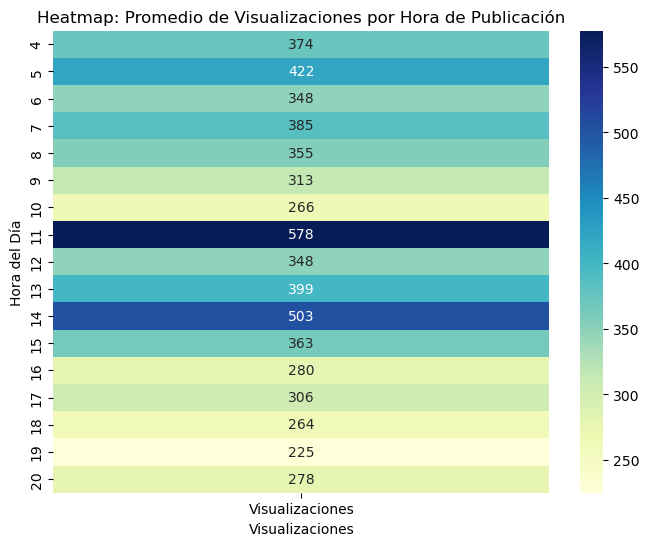

In [55]:
# --- Heatmap: Visualizaciones por Hora ---
heatmap_data = df_stories.groupby("Hora")["Visualizaciones"].mean().reset_index()
heatmap_data = heatmap_data.pivot_table(index="Hora", values="Visualizaciones")
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Heatmap: Promedio de Visualizaciones por Hora de Publicación")
plt.xlabel("Visualizaciones")
plt.ylabel("Hora del Día")
plt.show()

In [56]:
# ==============================================
# TOP 5 HISTORIAS POR MÉTRICAS
# ==============================================

print("=" * 80)
print("📊 TOP 5 HISTORIAS CON MÁS 'ME GUSTA'")
print("=" * 80)
top_5_likes = df_stories.nlargest(5, 'Me gusta')[['Hora de publicación', 'Me gusta']]
for idx, (i, row) in enumerate(top_5_likes.iterrows(), 1):
    print(f"\n🔝 #{idx} - Me gusta: {row['Me gusta']}")
    print(f"Hora de publicación: {row['Hora de publicación']}")
    print("-" * 80)

print("\n" + "=" * 80)
print("👁️ TOP 5 HISTORIAS CON MÁS 'VISUALIZACIONES'")
print("=" * 80)
top_5_views = df_stories.nlargest(5, 'Visualizaciones')[['Hora de publicación', 'Visualizaciones']]
for idx, (i, row) in enumerate(top_5_views.iterrows(), 1):
    print(f"\n🔝 #{idx} - Visualizaciones: {row['Visualizaciones']}")
    print(f"Hora de publicación: {row['Hora de publicación']}")
    print("-" * 80)

print("\n" + "=" * 80)
print("📈 TOP 5 HISTORIAS CON MÁS 'ALCANCE'")
print("=" * 80)
top_5_reach = df_stories.nlargest(5, 'Alcance')[['Hora de publicación', 'Alcance']]
for idx, (i, row) in enumerate(top_5_reach.iterrows(), 1):
    print(f"\n🔝 #{idx} - Alcance: {row['Alcance']}")
    print(f"Hora de publicación: {row['Hora de publicación']}")
    print("-" * 80)


📊 TOP 5 HISTORIAS CON MÁS 'ME GUSTA'

🔝 #1 - Me gusta: 22
Hora de publicación: 2026-02-13 06:31:00
--------------------------------------------------------------------------------

🔝 #2 - Me gusta: 22
Hora de publicación: 2026-02-13 09:54:00
--------------------------------------------------------------------------------

🔝 #3 - Me gusta: 22
Hora de publicación: 2026-02-15 04:16:00
--------------------------------------------------------------------------------

🔝 #4 - Me gusta: 19
Hora de publicación: 2026-02-12 16:50:00
--------------------------------------------------------------------------------

🔝 #5 - Me gusta: 19
Hora de publicación: 2026-02-13 17:47:00
--------------------------------------------------------------------------------

👁️ TOP 5 HISTORIAS CON MÁS 'VISUALIZACIONES'

🔝 #1 - Visualizaciones: 1100
Hora de publicación: 2026-02-14 14:05:00
--------------------------------------------------------------------------------

🔝 #2 - Visualizaciones: 861
Hora de publicación: 

--- Resumen del Archivo ---
Total de filas: 250
Columnas con datos: 580

--- Columnas Disponibles para Correlación ---
['Campaign ID', 'Creation Package Config ID', 'Campaign Name', 'Special Ad Categories', 'Special Ad Category Country', 'Campaign Status', 'Campaign Objective', 'Buying Type', 'Campaign Spend Limit', 'Campaign Daily Budget', 'Campaign Lifetime Budget', 'Campaign Bid Strategy', 'Tags', 'Campaign Is Using L3 Schedule', 'Campaign Start Time', 'Campaign Stop Time', 'Product Catalog ID', 'Campaign Page ID', 'New Objective', 'Buy With Prime Type', 'Is Budget Scheduling Enabled For Campaign', 'Campaign High Demand Periods', 'Buy With Integration Partner', 'Ad Set ID', 'Ad Set Run Status', 'Ad Set Lifetime Impressions', 'Ad Set Name', 'Ad Set Time Start', 'Ad Set Time Stop', 'Ad Set Daily Budget', 'Destination Type', 'Ad Set Lifetime Budget', 'Rate Card', 'Ad Set Schedule', 'Use Accelerated Delivery', 'Frequency Control', 'Ad Set Minimum Spend Limit', 'Ad Set Maximum Spend Limi

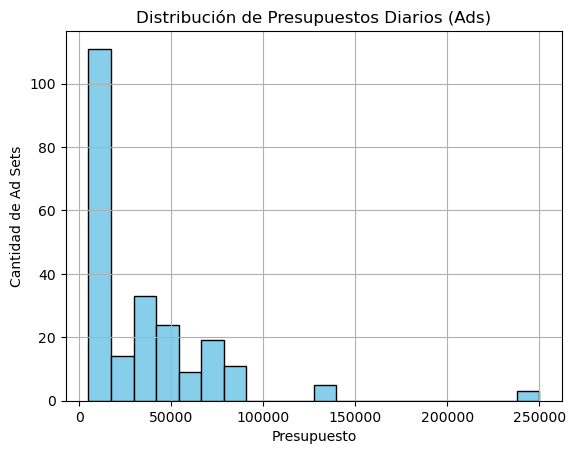

In [5]:
# 3. Mostrar información básica
print("--- Resumen del Archivo ---")
print(f"Total de filas: {df_pauta.shape[0]}")
print(f"Columnas con datos: {df_pauta.shape[1]}")
print("\n--- Columnas Disponibles para Correlación ---")
print(df_pauta.columns.tolist())

# 4. Análisis de Objetivos de Campaña
print("\n--- Distribución por Objetivo de Campaña ---")
print(df_pauta['Campaign Objective'].value_counts())

# 5. Análisis de Presupuesto Diario por Ad Set
if 'Ad Set Daily Budget' in df_pauta.columns:
    print("\n--- Estadísticas de Presupuesto Diario ---")
    print(df_pauta['Ad Set Daily Budget'].describe())
    
    # Visualización simple de presupuestos
    df_pauta['Ad Set Daily Budget'].hist(bins=20, color='skyblue', edgecolor='black')
    plt.title('Distribución de Presupuestos Diarios (Ads)')
    plt.xlabel('Presupuesto')
    plt.ylabel('Cantidad de Ad Sets')
    plt.savefig('distribucion_presupuestos.png')
    print("\nGráfico 'distribucion_presupuestos.png' generado.")

# 6. Identificación de Temas (vía nombres de campaña)
print("\n--- Top 10 Campañas por frecuencia ---")
print(df_pauta['Campaign Name'].value_counts().head(10))

--- Matriz de Correlación (Ads vs Orgánico) ---
                             Día  Importe gastado (COP)  Alcance_Organico  \
Día                     1.000000               0.502156          0.831294   
Importe gastado (COP)   0.502156               1.000000          0.516375   
Alcance_Organico        0.831294               0.516375          1.000000   
Interacciones_Organico  0.827860               0.473069          0.997035   

                        Interacciones_Organico  
Día                                   0.827860  
Importe gastado (COP)                 0.473069  
Alcance_Organico                      0.997035  
Interacciones_Organico                1.000000  


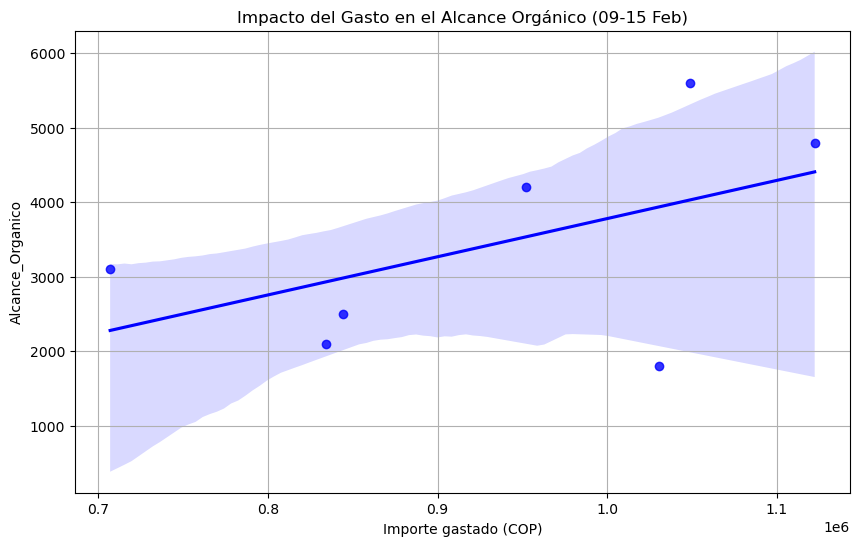

In [10]:
df_ads['Día'] = pd.to_datetime(df_ads['Día'])

# 2. Agrupar gasto por día (para consolidar si hay varias campañas)
gasto_diario = df_ads.groupby('Día')['Importe gastado (COP)'].sum().reset_index()

# 3. Crear DataFrame de métricas orgánicas del periodo (09-15 Feb)
# (Reemplaza estos valores con los datos reales de tus publicaciones)
data_organica = {
    'Día': pd.to_datetime(['2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-14', '2026-02-15']),
    'Alcance_Organico': [2100, 2500, 1800, 4200, 3100, 5600, 4800], # Datos de ejemplo
    'Interacciones_Organico': [45, 62, 38, 120, 85, 160, 130]      # Datos de ejemplo
}
df_org = pd.DataFrame(data_organica)

# 4. Unir ambas tablas
df_final = pd.merge(gasto_diario, df_org, on='Día')

# 5. Calcular Matriz de Correlación
correlacion = df_final.corr()
print("--- Matriz de Correlación (Ads vs Orgánico) ---")
print(correlacion)

# 6. Visualización: Relación Gasto vs Alcance
plt.figure(figsize=(10,6))
sns.regplot(data=df_final, x='Importe gastado (COP)', y='Alcance_Organico', color='blue')
plt.title('Impacto del Gasto en el Alcance Orgánico (09-15 Feb)')
plt.grid(True)
plt.show()

In [137]:
# Leer archivo de Excel (ajusta el nombre/ruta si es necesario)
archivo = r"C:\Users\57317\Desktop\PowerUps\JCVL\Web_Scrapping\tweets_samy_senador.xlsx"

# Leer la hoja
tweets_df = pd.read_excel(archivo)

# Separar las líneas de cada tweet
tweets_df["lines"] = tweets_df["tweet"].str.split("\n")

# Procesar cada tweet
processed_tweets = []

for index, row in tweets_df.iterrows():
    lines = row['lines']
    
    author = None
    username = None
    time = None
    content = []
    comments = None
    reposts = None
    likes = None
    
    # Detectar si es repost
    if "reposteó" in lines[0]:
        author_line = lines[1] if len(lines) > 1 else None
        username_line = lines[2] if len(lines) > 2 else None
        time_line = lines[3] if len(lines) > 3 else None
        tweet_content = lines[4:-1] if len(lines) > 5 else lines[4:]
    else:
        author_line = lines[0] if len(lines) > 0 else None
        username_line = lines[1] if len(lines) > 1 else None
        time_line = lines[3] if len(lines) > 3 else None
        tweet_content = lines[4:-1] if len(lines) > 5 else lines[4:]

    # Asignar valores
    author = author_line
    username = username_line
    time = time_line
    content = " ".join(tweet_content).strip()
    
    # Extraer métricas si están disponibles
    if len(lines) > 0:
        last_line = lines[-1]
        if "Me gusta" in last_line or "Comentarios" in last_line or "Reposts" in last_line:
            try:
                parts = last_line.replace("Me gusta", "").replace("Comentarios", "").replace("Reposts", "").split()
                comments = parts[0] if len(parts) > 0 else None
                reposts = parts[1] if len(parts) > 1 else None
                likes = parts[2] if len(parts) > 2 else None
            except:
                pass
    
    processed_tweets.append({
        "Autor": author,
        "Usuario": username,
        "Hora": time,
        "Contenido": content,
        "Comentarios": comments,
        "Reposts": reposts,
        "Me gusta": likes
    })

# Crear DataFrame limpio
tweets_limpio = pd.DataFrame(processed_tweets)

# Mostrar primeras filas para validar
print(tweets_limpio.head())

# Exportar a Excel
tweets_limpio.to_excel("tweets_samy_organizado.xlsx", index=False)
print("Archivo exportado exitosamente como 'tweets_samy_organizado.xlsx'")


          Autor        Usuario     Hora  \
0  Samy Senador  @Samy_senador      16h   
1  Samy Senador  @Samy_senador  20 may.   
2  Samy Senador  @Samy_senador  15 may.   
3  Samy Senador  @Samy_senador  15 may.   
4  Samy Senador  @Samy_senador  20 may.   

                                           Contenido Comentarios Reposts  \
0  Firmamos y apoyamos la ponencia positiva de la...        None    None   
1  Comparto entrevista en  @NoticiasCaracol  sobr...        None    None   
2                                                  1        None    None   
3  Celebramos la aprobación en primer debate de n...        None    None   
4  Comparto entrevista en  @NoticiasCaracol  sobr...        None    None   

  Me gusta  
0     None  
1     None  
2     None  
3     None  
4     None  
Archivo exportado exitosamente como 'tweets_samy_organizado.xlsx'


In [138]:
file_path4 = "new-form.csv"

In [139]:
import pandas as pd

# Paso 1: Definir la ruta del archivo original
archivo_original = file_path4

# Paso 2: Leer todo el archivo como texto
with open(archivo_original, 'r', encoding='utf-8') as archivo:
    lineas = archivo.readlines()

# Paso 3: Eliminar la primera línea si contiene contenido HTML (como <input ... />)
# Esto es común en formularios exportados desde plataformas web
if lineas[0].strip().startswith('<'):
    lineas = lineas[1:]

# Paso 4: Reemplazar caracteres HTML escapados como &quot; por comillas dobles reales
lineas = [linea.replace('&quot;', '"') for linea in lineas]

# Paso 5: Guardar el archivo limpio temporalmente como texto plano
archivo_temporal = 'Formulario_limpio.csv'
with open(archivo_temporal, 'w', encoding='utf-8') as archivo:
    archivo.writelines(lineas)

# Paso 6: Leer el archivo limpio con pandas
# pandas usará la primera línea como encabezado por defecto
df_form = pd.read_csv(archivo_temporal)

# Paso 7 (opcional): Mostrar las primeras filas para verificar
print(df_form.head())

# Nota: Si necesitas exportar nuevamente puedes usar:
# df.to_csv('Formulario_limpio.csv', index=False)


   2025-10-14 02:20:34  Juntos podemos  New Form  Unnamed: 3  \
0  2025-10-12 19:33:35  Juntos podemos  New Form         NaN   
1  2025-10-12 19:22:42  Juntos podemos  New Form         NaN   
2  2025-10-09 13:17:29  Juntos podemos  New Form         NaN   
3  2025-10-09 13:12:26  Juntos podemos  New Form         NaN   
4  2025-10-09 13:10:11  Juntos podemos  New Form         NaN   

        Libia ríos Gómez               Tulua  34056626  3146663620  \
0           Mireyapatiño  Cali.balledelcauca  27268258  3183693682   
1  Mireya.patiño..obando   Caliballedelcauca  27268258  3183693682   
2                      1                   2         3           4   
3                      1                   2         3           4   
4                      1                   2         3           4   

  libiariosgomez255@homail.com  Si Si.1 Educación básica secundaria  \
0        mireyap267@gimeil.com  Si   Si   Educación básica primaria   
1         mireyap267@gmeil.com  Si   Si        Sin e

In [140]:
df_form.columns

Index(['2025-10-14 02:20:34', 'Juntos podemos', 'New Form', 'Unnamed: 3',
       'Libia ríos Gómez', 'Tulua', '34056626', '3146663620',
       'libiariosgomez255@homail.com', 'Si', 'Si.1',
       'Educación básica secundaria',
       'Cuidar más los jóvenes del reclutamiento'],
      dtype='object')

In [141]:
# Ensure the column is datetime
_col = '2025-10-14 02:20:34'
if _col in df_form.columns:
    _dt_series = pd.to_datetime(df_form[_col], errors='coerce')

    # Define the range (order-agnostic)
    _a = pd.to_datetime('2025-10-09 13:17:29')
    _b = pd.to_datetime('2025-10-09 07:40:53')
    _start, _end = (min(_a, _b), max(_a, _b))

    # Drop rows where the datetime falls within [start, end]
    _mask_drop = _dt_series.between(_start, _end, inclusive='both')
    df_form = df_form.loc[~_mask_drop].copy()

    # Clean up temp vars
    del _dt_series, _a, _b, _start, _end, _mask_drop
else:
    raise KeyError(f"La columna {_col!r} no existe en df_form")

In [142]:
df_form

,2025-10-14 02:20:34,Juntos podemos,New Form,Unnamed: 3,Libia ríos Gómez,Tulua,34056626,3146663620,libiariosgomez255@homail.com,Si,Si.1,Educación básica secundaria,Cuidar más los jóvenes del reclutamiento
0,2025-10-12 19:33:35,Juntos podemos,New Form,NaN,Mireyapatiño,Cali.balledelcauca,27268258,3183693682,mireyap267@gimeil.com,Si,Si,Educación básica primaria,1maguina.plana.. 1maguinacoyerin 1brochadora 1...
1,2025-10-12 19:22:42,Juntos podemos,New Form,NaN,Mireya.patiño..obando,Caliballedelcauca,27268258,3183693682,mireyap267@gmeil.com,Si,Si,Sin educación formal,1maguinaplana 1.collarin 1.brochadora Plancca....
14,2025-09-28 22:51:25,Juntos podemos,New Form,NaN,Mario Valencia Franco,Pereira,9871969,3103542425,mavalencia81@hotmail.com,No,Si,Especialización,Propongo efectuar una serie de cambios desde l...
15,2025-09-28 06:43:00,Juntos podemos,New Form,NaN,Alexandra Vélez botero,Tulua,29901317,3187799824,alexandrvelezbotero@gmail.com,Si,Si,Educación básica secundaria,La verdad las ideas sobran la falta de oportun...
16,2025-09-17 20:04:30,Juntos podemos,New Form,NaN,Juan Pablo Ramírez Osorio,Tulua,1116237175,+573185274188,jproah1987@gmail.com,No,No,Pregrado,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,2025-03-18 10:04:48,Juntos podemos,New Form,NaN,Oscar Eduardo tangarife,3160672884,obandooscareduardo2@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN
75,2025-03-18 08:27:11,Juntos podemos,New Form,NaN,Nestor Ivan Cotte Moreno,3159273579,nestorcotte@hotmail.com,NaN,NaN,NaN,NaN,NaN,NaN
76,2025-03-18 08:22:13,Juntos podemos,New Form,NaN,Jhon Jairo Osorio Castaño,3154364874,fhilo2015@gmail.com,Siempre he soñado por un mejor pais,NaN,NaN,NaN,NaN,NaN
77,2025-03-18 08:22:09,Juntos podemos,New Form,NaN,Salomón ortiz motoa,3162921794,salomono7@hotmail.com,"Vamos por ese senado, necesitamos ser represen...",NaN,NaN,NaN,NaN,NaN


In [143]:
# Recreate the mask just to verify 0 remain in the range
_col = '2025-10-14 02:20:34'
_dt = pd.to_datetime(df_form[_col], errors='coerce')
(_dt.between(pd.to_datetime('2025-10-09 07:40:53'),
             pd.to_datetime('2025-10-09 13:17:29'), inclusive='both')).sum()

0

In [144]:
df_form

,2025-10-14 02:20:34,Juntos podemos,New Form,Unnamed: 3,Libia ríos Gómez,Tulua,34056626,3146663620,libiariosgomez255@homail.com,Si,Si.1,Educación básica secundaria,Cuidar más los jóvenes del reclutamiento
0,2025-10-12 19:33:35,Juntos podemos,New Form,NaN,Mireyapatiño,Cali.balledelcauca,27268258,3183693682,mireyap267@gimeil.com,Si,Si,Educación básica primaria,1maguina.plana.. 1maguinacoyerin 1brochadora 1...
1,2025-10-12 19:22:42,Juntos podemos,New Form,NaN,Mireya.patiño..obando,Caliballedelcauca,27268258,3183693682,mireyap267@gmeil.com,Si,Si,Sin educación formal,1maguinaplana 1.collarin 1.brochadora Plancca....
14,2025-09-28 22:51:25,Juntos podemos,New Form,NaN,Mario Valencia Franco,Pereira,9871969,3103542425,mavalencia81@hotmail.com,No,Si,Especialización,Propongo efectuar una serie de cambios desde l...
15,2025-09-28 06:43:00,Juntos podemos,New Form,NaN,Alexandra Vélez botero,Tulua,29901317,3187799824,alexandrvelezbotero@gmail.com,Si,Si,Educación básica secundaria,La verdad las ideas sobran la falta de oportun...
16,2025-09-17 20:04:30,Juntos podemos,New Form,NaN,Juan Pablo Ramírez Osorio,Tulua,1116237175,+573185274188,jproah1987@gmail.com,No,No,Pregrado,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,2025-03-18 10:04:48,Juntos podemos,New Form,NaN,Oscar Eduardo tangarife,3160672884,obandooscareduardo2@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN
75,2025-03-18 08:27:11,Juntos podemos,New Form,NaN,Nestor Ivan Cotte Moreno,3159273579,nestorcotte@hotmail.com,NaN,NaN,NaN,NaN,NaN,NaN
76,2025-03-18 08:22:13,Juntos podemos,New Form,NaN,Jhon Jairo Osorio Castaño,3154364874,fhilo2015@gmail.com,Siempre he soñado por un mejor pais,NaN,NaN,NaN,NaN,NaN
77,2025-03-18 08:22:09,Juntos podemos,New Form,NaN,Salomón ortiz motoa,3162921794,salomono7@hotmail.com,"Vamos por ese senado, necesitamos ser represen...",NaN,NaN,NaN,NaN,NaN


In [145]:
# --- Exportar CSV ---
OUTPUT_CSV = "./Formulario_limpio.csv"
df_form.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print("Archivo exportado:", OUTPUT_CSV)


Archivo exportado: ./Formulario_limpio.csv


In [146]:
# ==============================================
# FASE 1. CARGA DE DATOS
# ==============================================

import pandas as pd
from pysentimiento import create_analyzer
from wordcloud import WordCloud
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
import nltk
# Cambiar el nombre del archivo según la red social
# Ejemplo: "facebook.txt", "instagram.txt", "tiktok.txt"
ruta_archivo = r"C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\Facebook.txt"

with open(ruta_archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

# Crear DataFrame
df = pd.DataFrame(lineas, columns=["comentario"])
df.head()


c:\Users\57317\anaconda3\envs\notebook_ejecutor_DtaScie\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,comentario
0,Jefferson Jaramillo Enciso\n
1,Hola Juan Camilo Velez Londoño te deje un pequ...
2,4 años\n
3,Responder\n
4,Juan Camilo Velez Londoño\n


In [147]:
# ==============================================
# FASE 2. LIMPIEZA DE TEXTO
# ==============================================

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)  # eliminar URLs
    texto = re.sub(r"@\w+", lambda m: m.group(0).lower(), texto)  # mantener menciones
    texto = re.sub(r"#(\w+)", lambda m: "#" + m.group(1).lower(), texto)  # mantener hashtags
    texto = re.sub(r"[^a-záéíóúñü@#\s]", "", texto)  # eliminar caracteres no deseados
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)
df.head()


,comentario,comentario_limpio
0,Jefferson Jaramillo Enciso\n,jefferson jaramillo enciso
1,Hola Juan Camilo Velez Londoño te deje un pequ...,hola juan camilo velez londoño te deje un pequ...
2,4 años\n,años
3,Responder\n,responder
4,Juan Camilo Velez Londoño\n,juan camilo velez londoño


In [148]:
!pip install pysentimiento

In [149]:
# ==============================================        
# FASE 3. ANÁLISIS DE SENTIMIENTO
# ==============================================
analyzer = create_analyzer(task="sentiment", lang="es")

df["sentimiento"] = df["comentario_limpio"].apply(lambda x: analyzer.predict(x).output)
df["sentimiento"].value_counts(normalize=True)


KeyboardInterrupt: 

In [ ]:
# ==============================================
# FASE 4. EXTRACCIÓN DE ENTIDADES
# ==============================================

def extraer_entidades(texto):
    usuarios = re.findall(r"@(\w+)", texto)
    hashtags = re.findall(r"#(\w+)", texto)
    palabras = re.findall(r"\b[a-záéíóúñü]{4,}\b", texto)  # palabras con más de 3 letras
    return usuarios, hashtags, palabras

df["usuarios"], df["hashtags"], df["palabras"] = zip(*df["comentario_limpio"].apply(extraer_entidades))
df.head()


,comentario,comentario_limpio,sentimiento,usuarios,hashtags,palabras
0,Jefferson Jaramillo Enciso\n,jefferson jaramillo enciso,NEU,[],[],"[jefferson, jaramillo, enciso]"
1,Hola Juan Camilo Velez Londoño te deje un pequ...,hola juan camilo velez londoño te deje un pequ...,POS,[],[],"[hola, juan, camilo, velez, londoño, deje, peq..."
2,4 años\n,años,NEU,[],[],[años]
3,Responder\n,responder,NEU,[],[],[responder]
4,Juan Camilo Velez Londoño\n,juan camilo velez londoño,NEU,[],[],"[juan, camilo, velez, londoño]"


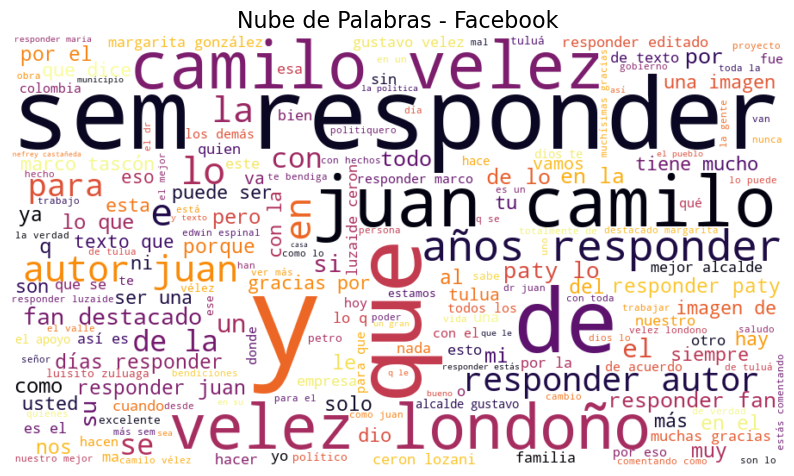

In [ ]:
# ==============================================
# FASE 5. NUBE DE PALABRAS
# ==============================================

# Verificar si comentario_limpio existe, si no, crearlo
if "comentario_limpio" not in df.columns:
    import re
    def limpiar_texto(texto):
        texto = str(texto).lower()
        texto = re.sub(r"http\S+", "", texto)  # eliminar URLs
        texto = re.sub(r"@\w+", lambda m: m.group(0).lower(), texto)  # mantener menciones
        texto = re.sub(r"#(\w+)", lambda m: "#" + m.group(1).lower(), texto)  # mantener hashtags
        texto = re.sub(r"[^a-záéíóúñü@#\s]", "", texto)  # eliminar caracteres no deseados
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto
    df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)

texto_total = " ".join(df["comentario_limpio"])
nube = WordCloud(width=900, height=500, background_color="white", colormap="inferno").generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Facebook", fontsize=16)
plt.show()


In [ ]:
!pip install networkx

In [ ]:
!pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 2.1 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 2.0 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\57317\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total de comentarios cargados: 5858


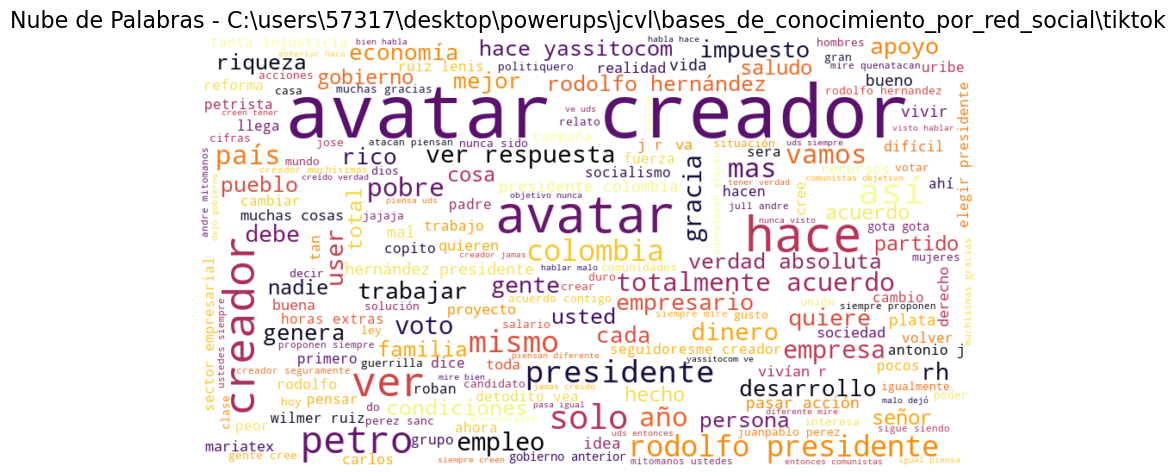

Red original: 2016 nodos, 13749 aristas
Red depurada: 200 nodos, 1287 aristas


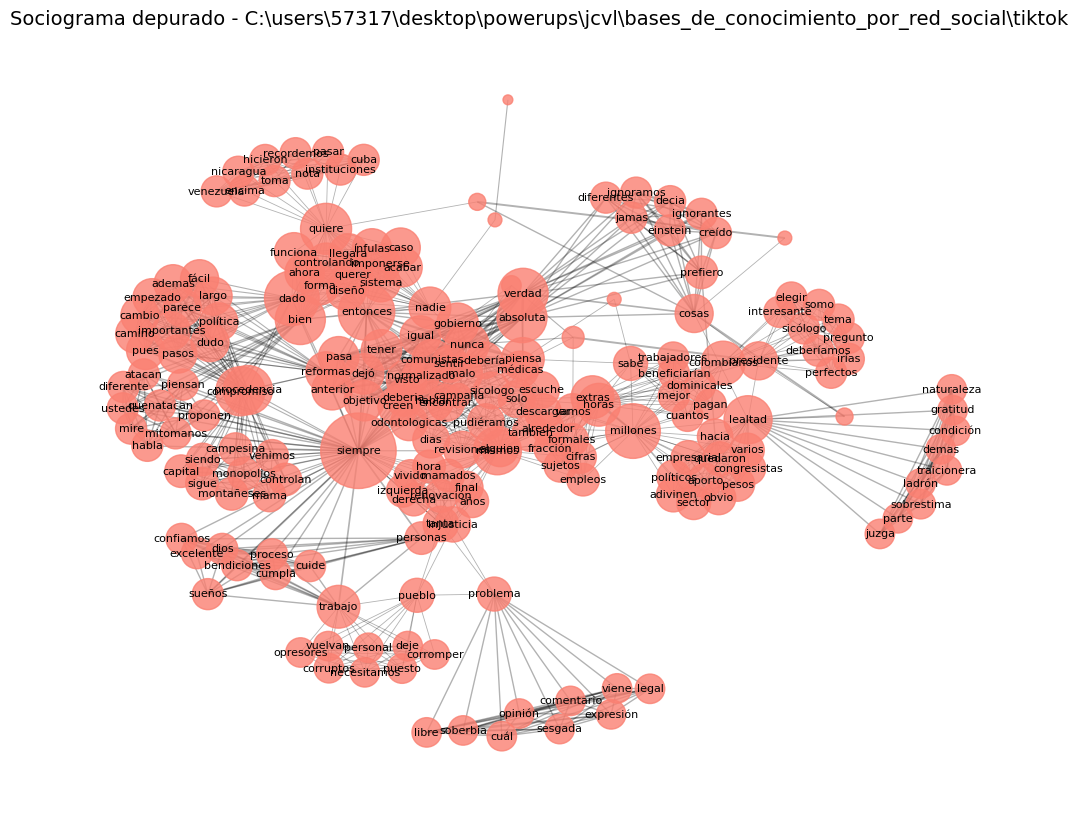

Densidad de la red: 0.065
Nodos más influyentes:
  siempre: 0.2965
  entonces: 0.1658
  dado: 0.1558
  millones: 0.1558
  quiere: 0.1357
Archivos exportados correctamente ✅


In [ ]:
# ======================================================
# SOCIOGRAMA DEPURADO POR RED SOCIAL (.TXT) - CON STOPWORDS PERSONALIZADAS
# ======================================================
nltk.download('stopwords')

# --- STOPWORDS: NLTK + PERSONALIZADAS ---
stop_words_nltk = set(stopwords.words('spanish'))

stop_words_custom = {
'responder','fannylu','juan','camilo','velez','semhace','ocultar','hresponder','semresponder',
    'perfil','es','una','día','dhace','dresponder','gustaresponder','díasresponder','alcaldiadetulua',
    'ahoraresponder','le','enviar','mensaje','sin','la','sume','te','días','h','responde','filtrado',
    'enlace','si','autor','alcalde','respuestas','click','tu','u','d','contestar','relevantes','sumada','será',
    'siguiente','algunas','puede','encuetas','encuestas','me','gusta','hacer','aquí','tulua','sem','q',
    'de','que','el','y','hijo','gustavo','papa','en','a','lo','se','para','por','los','un','no','las','al','ser','con','del'}

# Unimos ambas listas
STOP_WORDS = stop_words_nltk | stop_words_custom

# Helper para limpiar texto de stopwords (incluyendo versiones con '#')
def eliminar_stopwords_en_texto(texto, stopset):
    # elimina tokens que sean iguales a stopwords (con o sin # delante)
    # construimos un patrón como: r'\b#?(palabra1|palabra2|...)\b'
    # escapamos por seguridad
    if not stopset:
        return texto
    patron = r'\b#?(%s)\b' % '|'.join(re.escape(w) for w in sorted(stopset, key=len, reverse=True))
    return re.sub(patron, ' ', texto)

# === FASE 2. CARGA DEL ARCHIVO TXT ===
ruta_archivo = r"C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\Tiktok.txt"  # Cambia según la red social
with open(ruta_archivo, "r", encoding="utf-8") as f:
    comentarios = f.readlines()

df = pd.DataFrame(comentarios, columns=["comentario"])
print(f"Total de comentarios cargados: {len(df)}")

# === FASE 3. LIMPIEZA DE TEXTO ===
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)              # eliminar URLs
    texto = re.sub(r"[^a-záéíóúñü@#\s]", "", texto)   # conservar @ y #
    texto = re.sub(r"\s+", " ", texto).strip()
    # eliminar stopwords personalizadas (también si llevan '#')
    texto = eliminar_stopwords_en_texto(texto, STOP_WORDS)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)

# === FASE 4. EXTRACCIÓN DE ENTIDADES ===
def extraer_entidades(texto):
    # extraemos
    usuarios = re.findall(r"@(\w+)", texto)
    hashtags = re.findall(r"#(\w+)", texto)
    palabras = re.findall(r"\b[a-záéíóúñü]{4,}\b", texto)

    # filtramos contra STOP_WORDS
    usuarios = [u for u in usuarios if u.lower() not in STOP_WORDS]
    hashtags = [h for h in hashtags if h.lower() not in STOP_WORDS]
    palabras = [p for p in palabras if p.lower() not in STOP_WORDS]
    return usuarios, hashtags, palabras

df["usuarios"], df["hashtags"], df["palabras"] = zip(*df["comentario_limpio"].apply(extraer_entidades))

# === FASE 5. NUBE DE PALABRAS (excluyendo STOP_WORDS) ===
# WordCloud permite pasar stopwords directamente; además ya limpiamos antes.
texto_total = " ".join(df["comentario_limpio"])
nube = WordCloud(
    width=900, height=500,
    background_color="white",
    colormap="inferno",
    stopwords=STOP_WORDS
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title(f"Nube de Palabras - {ruta_archivo.split('.')[0].capitalize()}", fontsize=16)
plt.show()

# === FASE 6. CONSTRUCCIÓN DEL GRAFO COMPLETO ===
G = nx.Graph()

for _, fila in df.iterrows():
    # ya vienen filtradas; volvemos a filtrar por seguridad
    usuarios = [u for u in fila["usuarios"] if u.lower() not in STOP_WORDS]
    hashtags = [h for h in fila["hashtags"] if h.lower() not in STOP_WORDS]
    palabras = [p for p in fila["palabras"] if p.lower() not in STOP_WORDS]

    entidades = [f"@{u}" for u in usuarios] + [f"#{h}" for h in hashtags] + palabras
    for a, b in itertools.combinations(set(entidades), 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)

print(f"Red original: {len(G.nodes)} nodos, {len(G.edges)} aristas")

# === FASE 7. DEPURACIÓN DE LA RED ===

# 1) Filtrar aristas poco frecuentes
min_freq = 3
edges_to_keep = [(a, b) for a, b, d in G.edges(data=True) if d['weight'] >= min_freq]
G_filtrado = G.edge_subgraph(edges_to_keep).copy()

# 2) Eliminar nodos que sean stopwords o demasiado cortos
nodos_validos = [n for n in G_filtrado.nodes if n.lower().lstrip('#@') not in STOP_WORDS and len(n) > 3]
G_filtrado = G_filtrado.subgraph(nodos_validos)

# 3) Mantener solo los nodos más conectados (opcional)
grados = dict(G_filtrado.degree())
top_nodos = sorted(grados, key=grados.get, reverse=True)[:200]
G_sub = G_filtrado.subgraph(top_nodos)

print(f"Red depurada: {len(G_sub.nodes)} nodos, {len(G_sub.edges)} aristas")

# === FASE 8. VISUALIZACIÓN DEL SOCIOGRAMA ===
color_map = []
for n in G_sub.nodes:
    if n.startswith('@'):
        color_map.append('skyblue')
    elif n.startswith('#'):
        color_map.append('lightgreen')
    else:
        color_map.append('salmon')

pos = nx.kamada_kawai_layout(G_sub)
sizes = [G_sub.degree(n)*50 for n in G_sub.nodes]

plt.figure(figsize=(13,10))
nx.draw_networkx_nodes(G_sub, pos, node_size=sizes, node_color=color_map, alpha=0.8)
nx.draw_networkx_edges(G_sub, pos, width=[d['weight']*0.2 for (_,_,d) in G_sub.edges(data=True)], alpha=0.3)

# Mostrar etiquetas solo de los nodos más conectados
labels = {n: n for n in G_sub.nodes if G_sub.degree(n) > 5}
nx.draw_networkx_labels(G_sub, pos, labels=labels, font_size=8)

plt.title(f"Sociograma depurado - {ruta_archivo.split('.')[0].capitalize()}", fontsize=14)
plt.axis("off")
plt.show()

# === FASE 9. MÉTRICAS DE RED ===
densidad = nx.density(G_sub)
centralidad = nx.degree_centrality(G_sub)
top_centrales = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Densidad de la red: {densidad:.3f}")
print("Nodos más influyentes:")
for nodo, valor in top_centrales:
    print(f"  {nodo}: {valor:.4f}")

# === FASE 10. EXPORTACIÓN DE RESULTADOS ===
# Extraer solo el nombre del archivo sin la ruta ni la extensión
nombre_base = os.path.splitext(os.path.basename(ruta_archivo))[0]
nx.write_gexf(G_sub, f"sociograma_{nombre_base}.gexf")
df.to_csv(f"analisis_{nombre_base}.csv", index=False)
print("Archivos exportados correctamente ✅")


In [ ]:
# ==============================================
# SOCIOGRAMA 3D → SOLO EXPORTAR A HTML (sin show)
# Requiere: pip install plotly
# Usa el grafo depurado G_sub ya construido
# ==============================================
import os, math
import plotly.graph_objects as go
import networkx as nx

# 1) Layout 3D con fuerzas (usa pesos si existen)
pos3d = nx.spring_layout(G_sub, dim=3, seed=42, weight="weight")

# 2) Aristas (segmentos 3D)
edge_x, edge_y, edge_z = [], [], []
for u, v in G_sub.edges():
    x0, y0, z0 = pos3d[u]
    x1, y1, z1 = pos3d[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(width=1.5, color="lightgray"),
    hoverinfo="none",
    name="Relaciones"
)

# 3) Nodos (color por tipo, tamaño por grado)
def node_type(n):
    s = str(n)
    if s.startswith("@"): return "usuario"
    if s.startswith("#"): return "hashtag"
    return "palabra"

def node_color(t):
    return {"usuario": "#4da3ff", "hashtag": "#7bd389", "palabra": "#ff7b7b"}.get(t, "#cccccc")

deg = dict(G_sub.degree())
max_deg = max(deg.values()) if deg else 1
min_size, max_size = 6, 26

node_x, node_y, node_z, node_size, node_color_list, node_hover = [], [], [], [], [], []
for n in G_sub.nodes():
    x, y, z = pos3d[n]
    node_x.append(x); node_y.append(y); node_z.append(z)
    t = node_type(n)
    node_color_list.append(node_color(t))
    s = min_size + (max_size - min_size) * (deg[n] / max_deg)
    node_size.append(s)
    node_hover.append(f"{n}<br>tipo: {t}<br>grado: {deg[n]}")

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode="markers",
    marker=dict(size=node_size, color=node_color_list, line=dict(color="#333", width=0.5), opacity=0.92),
    hovertext=node_hover,
    hoverinfo="text",
    name="Nodos"
)

# 4) Figura y layout (sin fig.show())
fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"Sociograma 3D interactivo - {str(ruta_archivo).split('.')[0]}",
    showlegend=False,
    margin=dict(l=0, r=0, t=50, b=0),
    scene=dict(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=""),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=""),
        zaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title="")
    ),
    paper_bgcolor="white",
)

# ==============================================
# LEYENDA INTERACTIVA (TOP-8 NODOS) + FOCO AUTOMÁTICO
# ==============================================

# --- 1) Selección de los 8 nodos más importantes (por grado) ---
top8 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8]
top8_nodos = [n for n, _ in top8]

# --- 2) Extremos globales del layout (para reset / spans) ---
xs = np.array([pos3d[n][0] for n in G_sub.nodes()])
ys = np.array([pos3d[n][1] for n in G_sub.nodes()])
zs = np.array([pos3d[n][2] for n in G_sub.nodes()])

xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()
zmin, zmax = zs.min(), zs.max()

# Rango total y span de zoom (ajusta el factor 0.25 según prefieras el “zoom”)
span_global = max(xmax - xmin, ymax - ymin, zmax - zmin)
zoom_span = span_global * 0.25

def ranges_alrededor(xc, yc, zc, span):
    half = span / 2.0
    return (
        [xc - half, xc + half],
        [yc - half, yc + half],
        [zc - half, zc + half],
    )

# --- 3) Botones del dropdown: uno por nodo y un Reset ---
buttons = []

# Botón Reset (restaura vista global)
buttons.append(dict(
    label="Reset",
    method="relayout",
    args=[{
        "scene.xaxis.range": [xmin, xmax],
        "scene.yaxis.range": [ymin, ymax],
        "scene.zaxis.range": [zmin, zmax],
    }],
))

# Un botón por cada nodo importante
for nodo in top8_nodos:
    x0, y0, z0 = pos3d[nodo]
    xr, yr, zr = ranges_alrededor(x0, y0, z0, zoom_span)
    buttons.append(dict(
        label=nodo,             # aparece en el dropdown
        method="relayout",      # al hacer click, actualiza rangos
        args=[{
            "scene.xaxis.range": xr,
            "scene.yaxis.range": yr,
            "scene.zaxis.range": zr,
        }],
    ))

# --- 4) Agregar el dropdown (leyenda interactiva) al layout ---
fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            showactive=True,
            x=0.02, y=0.98, xanchor="left", yanchor="top",
            buttons=buttons,
            bgcolor="white",
            bordercolor="#ccc",
            borderwidth=1,
            font=dict(size=12),
        )
    ],
    # (Opcional) Una pequeña leyenda de color por tipo de nodo
    annotations=[
        dict(
            x=1.02, y=0.98, xref="paper", yref="paper",
            text="<b>Leyenda</b><br>"
                 "<span style='color:#4da3ff'>●</span> @usuario<br>"
                 "<span style='color:#7bd389'>●</span> #hashtag<br>"
                 "<span style='color:#ff7b7b'>●</span> palabra",
            showarrow=False, align="left", bgcolor="white", bordercolor="#ccc", borderwidth=1, borderpad=6
        )
    ]
)

# (Opcional) Arranque con vista global “bonita”
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[xmin, xmax]),
        yaxis=dict(range=[ymin, ymax]),
        zaxis=dict(range=[zmin, zmax]),
    )
)

# ================================
# LEYENDA GRANDE + DROPDOWN GRANDE
# ================================

# --- márgenes generosos para que nada se corte ---
RIGHT_MARGIN = 260  # <- ajústalo si aún queda justo
TOP_MARGIN   = 100
fig.update_layout(margin=dict(l=20, r=RIGHT_MARGIN, t=TOP_MARGIN, b=20))

# --- vista global inicial (útil para Reset) ---
xs = np.array([pos3d[n][0] for n in G_sub.nodes()])
ys = np.array([pos3d[n][1] for n in G_sub.nodes()])
zs = np.array([pos3d[n][2] for n in G_sub.nodes()])
xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()
zmin, zmax = zs.min(), zs.max()

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[xmin, xmax], showgrid=False, zeroline=False, showticklabels=False, title=""),
        yaxis=dict(range=[ymin, ymax], showgrid=False, zeroline=False, showticklabels=False, title=""),
        zaxis=dict(range=[zmin, zmax], showgrid=False, zeroline=False, showticklabels=False, title="")
    )
)

# --- TOP-8 por grado (si no lo tienes ya calculado) ---
deg = dict(G_sub.degree())
top8 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8]
top8_nodos = [n for n, _ in top8]

# util para ranges al enfocar un nodo
span_global = max(xmax - xmin, ymax - ymin, zmax - zmin)
zoom_span = span_global * 0.25  # más pequeño = más zoom
def ranges_alrededor(xc, yc, zc, span):
    half = span / 2.0
    return [xc - half, xc + half], [yc - half, yc + half], [zc - half, zc + half]

# --- botones: Reset + un botón por nodo top8 ---
buttons = []

# Reset primero para que sea el label visible inicial (showactive=True)
buttons.append(dict(
    label="Reset",
    method="relayout",
    args=[{
        "scene.xaxis.range": [xmin, xmax],
        "scene.yaxis.range": [ymin, ymax],
        "scene.zaxis.range": [zmin, zmax],
    }],
))

for nodo in top8_nodos:
    x0, y0, z0 = pos3d[nodo]
    xr, yr, zr = ranges_alrededor(x0, y0, z0, zoom_span)
    buttons.append(dict(
        label=str(nodo),
        method="relayout",
        args=[{
            "scene.xaxis.range": xr,
            "scene.yaxis.range": yr,
            "scene.zaxis.range": zr,
        }],
    ))

# --- Dropdown grande (fuente y padding aumentados) ---
fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        active=0,                    # muestra "Reset" como texto del botón
        x=0.02, y=0.98,              # esquina superior izquierda
        xanchor="left", yanchor="top",
        bgcolor="white",
        bordercolor="#888",
        borderwidth=1,
        font=dict(size=16),          # << tamaño de letra del dropdown
        pad=dict(l=10, r=10, t=8, b=8),
        buttons=buttons
    )]
)

# --- Leyenda grande a la derecha (como anotación) ---
# aumentamos font y borderpad; movemos un poquito con x para que respire
fig.update_layout(
    annotations=[dict(
        x=1.01, y=0.98, xref="paper", yref="paper",  # 1.01 + margen derecho amplio = no se corta
        text=(
            "<b>Leyenda</b><br>"
            "<span style='color:#4da3ff'>●</span> @usuario<br>"
            "<span style='color:#7bd389'>●</span> #hashtag<br>"
            "<span style='color:#ff7b7b'>●</span> palabra"
        ),
        showarrow=False, align="left",
        bgcolor="white", bordercolor="#888", borderwidth=1,
        borderpad=10,                # << acolchado interno del recuadro
        font=dict(size=16)           # << tamaño de letra del recuadro
    )]
)

# 5) Guardar HTML junto al txt de origen
base_dir = os.path.dirname(ruta_archivo) if 'ruta_archivo' in globals() else os.getcwd()
output_html = os.path.join(base_dir, "sociograma_3d_interactivo.html")
fig.write_html(output_html, include_plotlyjs="cdn", full_html=True)
print(f"HTML exportado ✅ → {output_html}")



HTML exportado ✅ → C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\sociograma_3d_interactivo.html


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\57317\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total de comentarios cargados: 3982


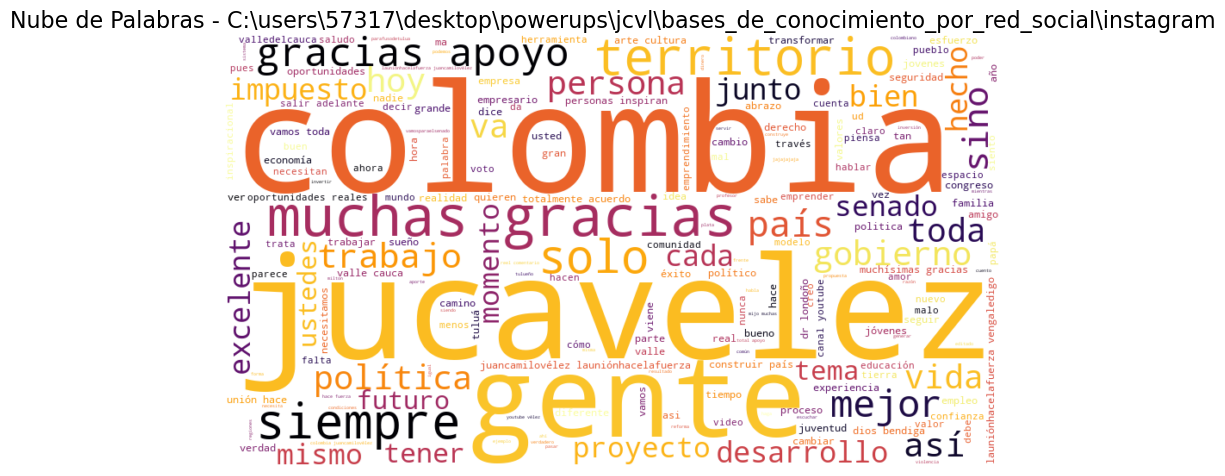

Red original: 4453 nodos, 79110 aristas
Red depurada: 200 nodos, 3227 aristas


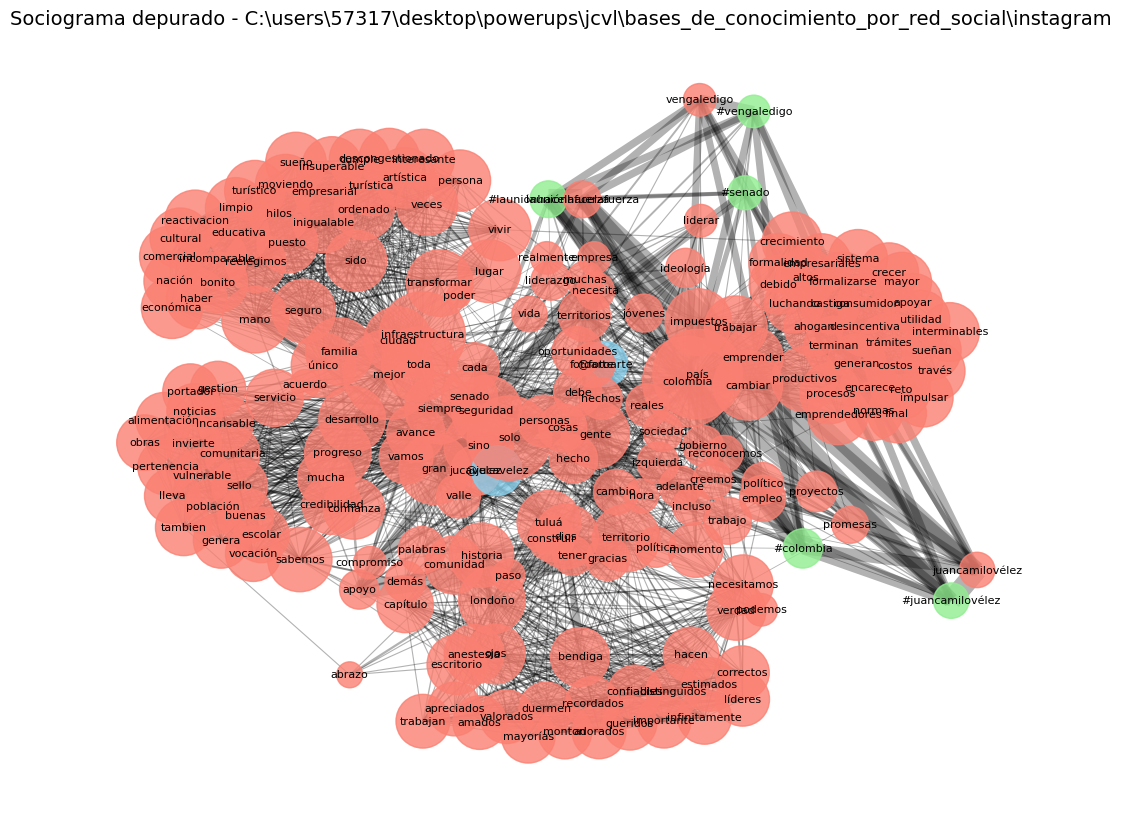

Densidad de la red: 0.162
Nodos más influyentes:
  colombia: 0.4271
  mejor: 0.4221
  país: 0.4171
  infraestructura: 0.3869
  solo: 0.3719
Archivos exportados correctamente ✅


In [ ]:
# ======================================================
# SOCIOGRAMA DEPURADO POR RED SOCIAL (.TXT) - CON STOPWORDS PERSONALIZADAS
# ======================================================
nltk.download('stopwords')

# --- STOPWORDS: NLTK + PERSONALIZADAS ---
stop_words_nltk = set(stopwords.words('spanish'))

stop_words_custom = {
    'responder','fannylu','juan','camilo','velez','semhace','ocultar','hresponder','semresponder',
    'perfil','es','una','día','dhace','dresponder','gustaresponder','díasresponder','alcaldiadetulua',
    'ahoraresponder','le','enviar','mensaje','sin','la','sume','te','días','h','responde','filtrado',
    'enlace','si','autor','alcalde','respuestas','click','tu','u','d','contestar','relevantes','sumada','será',
    'siguiente','algunas','puede','encuetas','encuestas','me','gusta','hacer','aquí','tulua','sem','q',
    'de','que','el','y','hijo','gustavo','papa','en','a','lo','se','para','por','los','un','no','las','al','ser','con','del'
}
# Unimos ambas listas
STOP_WORDS = stop_words_nltk | stop_words_custom

# Helper para limpiar texto de stopwords (incluyendo versiones con '#')
def eliminar_stopwords_en_texto(texto, stopset):
    # elimina tokens que sean iguales a stopwords (con o sin # delante)
    # construimos un patrón como: r'\b#?(palabra1|palabra2|...)\b'
    # escapamos por seguridad
    if not stopset:
        return texto
    patron = r'\b#?(%s)\b' % '|'.join(re.escape(w) for w in sorted(stopset, key=len, reverse=True))
    return re.sub(patron, ' ', texto)

# === FASE 2. CARGA DEL ARCHIVO TXT ===
ruta_archivo = r"C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\Instagram.txt"  # Cambia según la red social
with open(ruta_archivo, "r", encoding="utf-8") as f:
    comentarios = f.readlines()

df = pd.DataFrame(comentarios, columns=["comentario"])
print(f"Total de comentarios cargados: {len(df)}")

# === FASE 3. LIMPIEZA DE TEXTO ===
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)              # eliminar URLs
    texto = re.sub(r"[^a-záéíóúñü@#\s]", "", texto)   # conservar @ y #
    texto = re.sub(r"\s+", " ", texto).strip()
    # eliminar stopwords personalizadas (también si llevan '#')
    texto = eliminar_stopwords_en_texto(texto, STOP_WORDS)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)

# === FASE 4. EXTRACCIÓN DE ENTIDADES ===
def extraer_entidades(texto):
    # extraemos
    usuarios = re.findall(r"@(\w+)", texto)
    hashtags = re.findall(r"#(\w+)", texto)
    palabras = re.findall(r"\b[a-záéíóúñü]{4,}\b", texto)

    # filtramos contra STOP_WORDS
    usuarios = [u for u in usuarios if u.lower() not in STOP_WORDS]
    hashtags = [h for h in hashtags if h.lower() not in STOP_WORDS]
    palabras = [p for p in palabras if p.lower() not in STOP_WORDS]
    return usuarios, hashtags, palabras

df["usuarios"], df["hashtags"], df["palabras"] = zip(*df["comentario_limpio"].apply(extraer_entidades))

# === FASE 5. NUBE DE PALABRAS (excluyendo STOP_WORDS) ===
# WordCloud permite pasar stopwords directamente; además ya limpiamos antes.
texto_total = " ".join(df["comentario_limpio"])
nube = WordCloud(
    width=900, height=500,
    background_color="white",
    colormap="inferno",
    stopwords=STOP_WORDS
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title(f"Nube de Palabras - {ruta_archivo.split('.')[0].capitalize()}", fontsize=16)
plt.show()

# === FASE 6. CONSTRUCCIÓN DEL GRAFO COMPLETO ===
G = nx.Graph()

for _, fila in df.iterrows():
    # ya vienen filtradas; volvemos a filtrar por seguridad
    usuarios = [u for u in fila["usuarios"] if u.lower() not in STOP_WORDS]
    hashtags = [h for h in fila["hashtags"] if h.lower() not in STOP_WORDS]
    palabras = [p for p in fila["palabras"] if p.lower() not in STOP_WORDS]

    entidades = [f"@{u}" for u in usuarios] + [f"#{h}" for h in hashtags] + palabras
    for a, b in itertools.combinations(set(entidades), 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)

print(f"Red original: {len(G.nodes)} nodos, {len(G.edges)} aristas")

# === FASE 7. DEPURACIÓN DE LA RED ===

# 1) Filtrar aristas poco frecuentes
min_freq = 3
edges_to_keep = [(a, b) for a, b, d in G.edges(data=True) if d['weight'] >= min_freq]
G_filtrado = G.edge_subgraph(edges_to_keep).copy()

# 2) Eliminar nodos que sean stopwords o demasiado cortos
nodos_validos = [n for n in G_filtrado.nodes if n.lower().lstrip('#@') not in STOP_WORDS and len(n) > 3]
G_filtrado = G_filtrado.subgraph(nodos_validos)

# 3) Mantener solo los nodos más conectados (opcional)
grados = dict(G_filtrado.degree())
top_nodos = sorted(grados, key=grados.get, reverse=True)[:200]
G_sub = G_filtrado.subgraph(top_nodos)

print(f"Red depurada: {len(G_sub.nodes)} nodos, {len(G_sub.edges)} aristas")

# === FASE 8. VISUALIZACIÓN DEL SOCIOGRAMA ===
color_map = []
for n in G_sub.nodes:
    if n.startswith('@'):
        color_map.append('skyblue')
    elif n.startswith('#'):
        color_map.append('lightgreen')
    else:
        color_map.append('salmon')

pos = nx.kamada_kawai_layout(G_sub)
sizes = [G_sub.degree(n)*50 for n in G_sub.nodes]

plt.figure(figsize=(13,10))
nx.draw_networkx_nodes(G_sub, pos, node_size=sizes, node_color=color_map, alpha=0.8)
nx.draw_networkx_edges(G_sub, pos, width=[d['weight']*0.2 for (_,_,d) in G_sub.edges(data=True)], alpha=0.3)

# Mostrar etiquetas solo de los nodos más conectados
labels = {n: n for n in G_sub.nodes if G_sub.degree(n) > 5}
nx.draw_networkx_labels(G_sub, pos, labels=labels, font_size=8)

plt.title(f"Sociograma depurado - {ruta_archivo.split('.')[0].capitalize()}", fontsize=14)
plt.axis("off")
plt.show()

# === FASE 9. MÉTRICAS DE RED ===
densidad = nx.density(G_sub)
centralidad = nx.degree_centrality(G_sub)
top_centrales = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Densidad de la red: {densidad:.3f}")
print("Nodos más influyentes:")
for nodo, valor in top_centrales:
    print(f"  {nodo}: {valor:.4f}")

# === FASE 10. EXPORTACIÓN DE RESULTADOS ===
# Extraer solo el nombre del archivo sin la ruta ni la extensión
nombre_base = os.path.splitext(os.path.basename(ruta_archivo))[0]
nx.write_gexf(G_sub, f"sociograma_{nombre_base}.gexf")
df.to_csv(f"analisis_{nombre_base}.csv", index=False)
print("Archivos exportados correctamente ✅")


In [ ]:
# ==============================================
# SOCIOGRAMA 3D → SOLO EXPORTAR A HTML (sin show)
# Requiere: pip install plotly
# Usa el grafo depurado G_sub ya construido
# ==============================================
import os, math
import plotly.graph_objects as go
import networkx as nx

# 1) Layout 3D con fuerzas (usa pesos si existen)
pos3d = nx.spring_layout(G_sub, dim=3, seed=42, weight="weight")

# 2) Aristas (segmentos 3D)
edge_x, edge_y, edge_z = [], [], []
for u, v in G_sub.edges():
    x0, y0, z0 = pos3d[u]
    x1, y1, z1 = pos3d[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(width=1.5, color="lightgray"),
    hoverinfo="none",
    name="Relaciones"
)

# 3) Nodos (color por tipo, tamaño por grado)
def node_type(n):
    s = str(n)
    if s.startswith("@"): return "usuario"
    if s.startswith("#"): return "hashtag"
    return "palabra"

def node_color(t):
    return {"usuario": "#4da3ff", "hashtag": "#7bd389", "palabra": "#ff7b7b"}.get(t, "#cccccc")

deg = dict(G_sub.degree())
max_deg = max(deg.values()) if deg else 1
min_size, max_size = 6, 26

node_x, node_y, node_z, node_size, node_color_list, node_hover = [], [], [], [], [], []
for n in G_sub.nodes():
    x, y, z = pos3d[n]
    node_x.append(x); node_y.append(y); node_z.append(z)
    t = node_type(n)
    node_color_list.append(node_color(t))
    s = min_size + (max_size - min_size) * (deg[n] / max_deg)
    node_size.append(s)
    node_hover.append(f"{n}<br>tipo: {t}<br>grado: {deg[n]}")

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode="markers",
    marker=dict(size=node_size, color=node_color_list, line=dict(color="#333", width=0.5), opacity=0.92),
    hovertext=node_hover,
    hoverinfo="text",
    name="Nodos"
)

# 4) Figura y layout (sin fig.show())
fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"Sociograma 3D interactivo - {str(ruta_archivo).split('.')[0]}",
    showlegend=False,
    margin=dict(l=0, r=0, t=50, b=0),
    scene=dict(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=""),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=""),
        zaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title="")
    ),
    paper_bgcolor="white",
)

# ================================
# LEYENDA GRANDE + DROPDOWN GRANDE
# ================================

# --- márgenes generosos para que nada se corte ---
RIGHT_MARGIN = 240  # <- ajústalo si aún queda justo
TOP_MARGIN   = 80
fig.update_layout(margin=dict(l=20, r=RIGHT_MARGIN, t=TOP_MARGIN, b=20))

# --- vista global inicial (útil para Reset) ---
xs = np.array([pos3d[n][0] for n in G_sub.nodes()])
ys = np.array([pos3d[n][1] for n in G_sub.nodes()])
zs = np.array([pos3d[n][2] for n in G_sub.nodes()])
xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()
zmin, zmax = zs.min(), zs.max()

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[xmin, xmax], showgrid=False, zeroline=False, showticklabels=False, title=""),
        yaxis=dict(range=[ymin, ymax], showgrid=False, zeroline=False, showticklabels=False, title=""),
        zaxis=dict(range=[zmin, zmax], showgrid=False, zeroline=False, showticklabels=False, title="")
    )
)

# --- TOP-8 por grado (si no lo tienes ya calculado) ---
deg = dict(G_sub.degree())
top8 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8]
top8_nodos = [n for n, _ in top8]

# util para ranges al enfocar un nodo
span_global = max(xmax - xmin, ymax - ymin, zmax - zmin)
zoom_span = span_global * 0.25  # más pequeño = más zoom
def ranges_alrededor(xc, yc, zc, span):
    half = span / 2.0
    return [xc - half, xc + half], [yc - half, yc + half], [zc - half, zc + half]

# --- botones: Reset + un botón por nodo top8 ---
buttons = []

# Reset primero para que sea el label visible inicial (showactive=True)
buttons.append(dict(
    label="Reset",
    method="relayout",
    args=[{
        "scene.xaxis.range": [xmin, xmax],
        "scene.yaxis.range": [ymin, ymax],
        "scene.zaxis.range": [zmin, zmax],
    }],
))

for nodo in top8_nodos:
    x0, y0, z0 = pos3d[nodo]
    xr, yr, zr = ranges_alrededor(x0, y0, z0, zoom_span)
    buttons.append(dict(
        label=str(nodo),
        method="relayout",
        args=[{
            "scene.xaxis.range": xr,
            "scene.yaxis.range": yr,
            "scene.zaxis.range": zr,
        }],
    ))

# --- Dropdown grande (fuente y padding aumentados) ---
fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        active=0,                    # muestra "Reset" como texto del botón
        x=0.02, y=0.98,              # esquina superior izquierda
        xanchor="left", yanchor="top",
        bgcolor="white",
        bordercolor="#888",
        borderwidth=1,
        font=dict(size=16),          # << tamaño de letra del dropdown
        pad=dict(l=10, r=10, t=8, b=8),
        buttons=buttons
    )]
)

# --- Leyenda grande a la derecha (como anotación) ---
# aumentamos font y borderpad; movemos un poquito con x para que respire
fig.update_layout(
    annotations=[dict(
        x=1.01, y=0.98, xref="paper", yref="paper",  # 1.01 + margen derecho amplio = no se corta
        text=(
            "<b>Leyenda</b><br>"
            "<span style='color:#4da3ff'>●</span> @usuario<br>"
            "<span style='color:#7bd389'>●</span> #hashtag<br>"
            "<span style='color:#ff7b7b'>●</span> palabra"
        ),
        showarrow=False, align="left",
        bgcolor="white", bordercolor="#888", borderwidth=1,
        borderpad=10,                # << acolchado interno del recuadro
        font=dict(size=16)           # << tamaño de letra del recuadro
    )]
)

# 5) Guardar HTML junto al txt de origen
base_dir = os.path.dirname(ruta_archivo) if 'ruta_archivo' in globals() else os.getcwd()
output_html = os.path.join(base_dir, "sociograma_3d_interactivo.html")
fig.write_html(output_html, include_plotlyjs="cdn", full_html=True)
print(f"HTML exportado ✅ → {output_html}")


HTML exportado ✅ → C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\sociograma_3d_interactivo.html


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\57317\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total de comentarios cargados: 7756


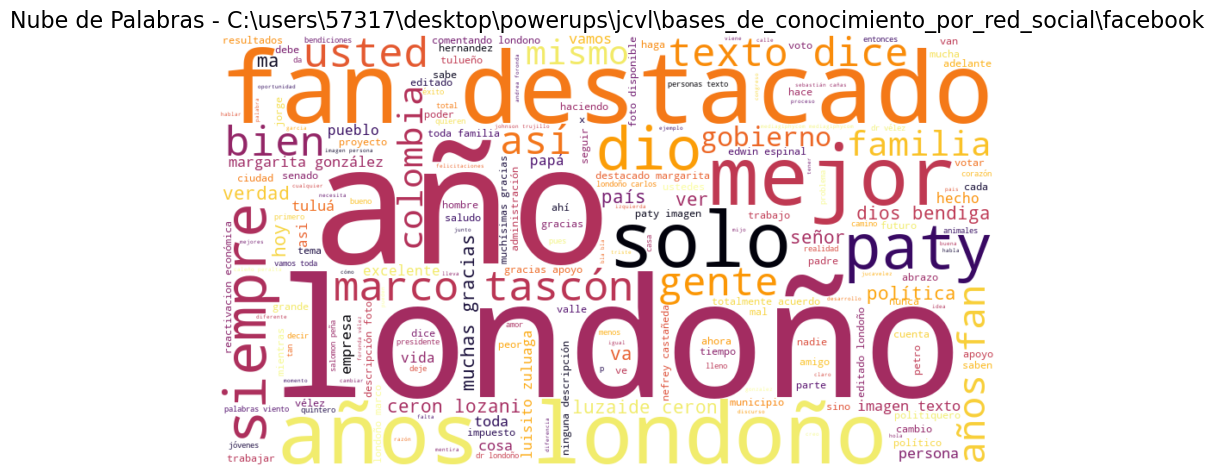

Red original: 5587 nodos, 110369 aristas
Red depurada: 200 nodos, 12575 aristas


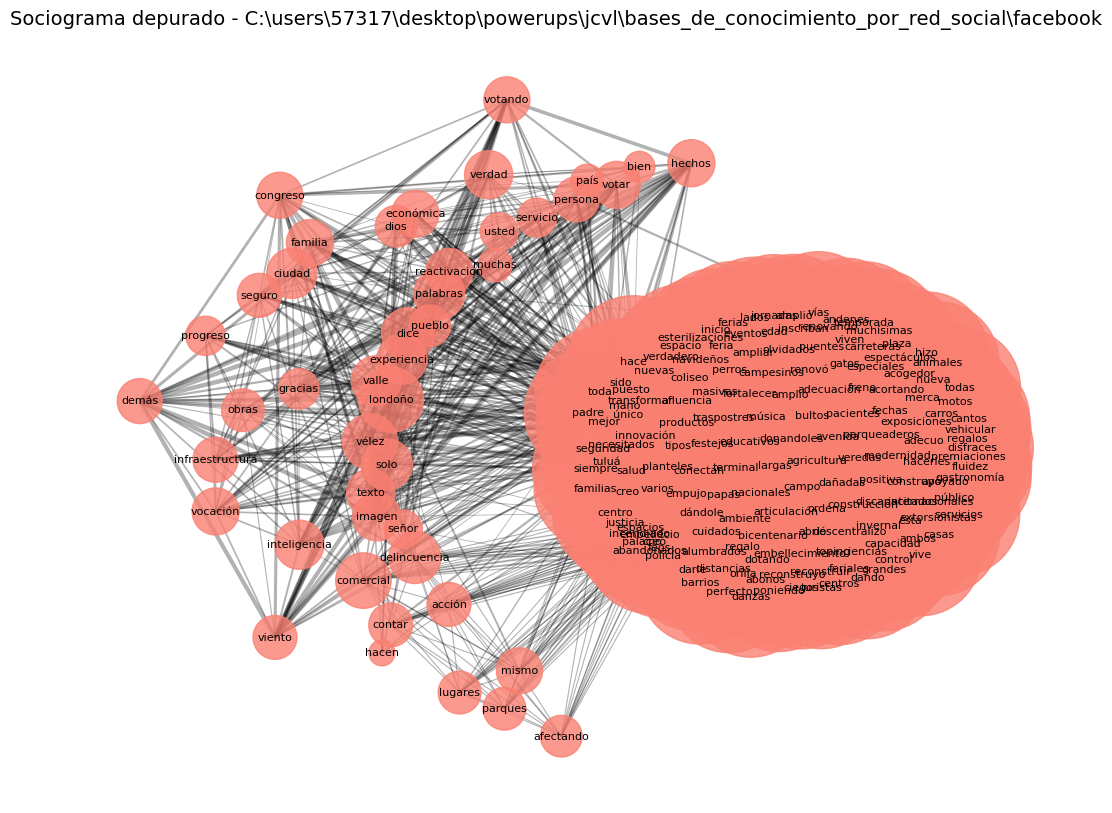

Densidad de la red: 0.632
Nodos más influyentes:
  mejor: 0.9648
  hace: 0.8945
  tuluá: 0.8894
  toda: 0.8794
  puesto: 0.8643
Archivos exportados correctamente ✅


In [ ]:
# ======================================================
# SOCIOGRAMA DEPURADO POR RED SOCIAL (.TXT) - CON STOPWORDS PERSONALIZADAS
# ======================================================
nltk.download('stopwords')

# --- STOPWORDS: NLTK + PERSONALIZADAS ---
stop_words_nltk = set(stopwords.words('spanish'))

stop_words_custom = {
'responder','fannylu','juan','camilo','velez','semhace','ocultar','hresponder','semresponder',
    'perfil','es','una','día','dhace','dresponder','gustaresponder','díasresponder','alcaldiadetulua',
    'ahoraresponder','le','enviar','mensaje','sin','la','sume','te','días','h','responde','filtrado',
    'enlace','si','autor','alcalde','respuestas','click','tu','u','d','contestar','relevantes','sumada','será',
    'siguiente','algunas','puede','encuetas','encuestas','me','gusta','hacer','aquí','tulua','sem','q',
    'de','que','el','y','hijo','gustavo','papa','gran','en','a','lo','se','para','por','los','un','no','las','al','ser','con','del'
}

# Unimos ambas listas
STOP_WORDS = stop_words_nltk | stop_words_custom

# Helper para limpiar texto de stopwords (incluyendo versiones con '#')
def eliminar_stopwords_en_texto(texto, stopset):
    # elimina tokens que sean iguales a stopwords (con o sin # delante)
    # construimos un patrón como: r'\b#?(palabra1|palabra2|...)\b'
    # escapamos por seguridad
    if not stopset:
        return texto
    patron = r'\b#?(%s)\b' % '|'.join(re.escape(w) for w in sorted(stopset, key=len, reverse=True))
    return re.sub(patron, ' ', texto)

# === FASE 2. CARGA DEL ARCHIVO TXT ===
ruta_archivo = r"C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\Facebook.txt"  # Cambia según la red social
with open(ruta_archivo, "r", encoding="utf-8") as f:
    comentarios = f.readlines()

df = pd.DataFrame(comentarios, columns=["comentario"])
print(f"Total de comentarios cargados: {len(df)}")

# === FASE 3. LIMPIEZA DE TEXTO ===
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)              # eliminar URLs
    texto = re.sub(r"[^a-záéíóúñü@#\s]", "", texto)   # conservar @ y #
    texto = re.sub(r"\s+", " ", texto).strip()
    # eliminar stopwords personalizadas (también si llevan '#')
    texto = eliminar_stopwords_en_texto(texto, STOP_WORDS)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)

# === FASE 4. EXTRACCIÓN DE ENTIDADES ===
def extraer_entidades(texto):
    # extraemos
    usuarios = re.findall(r"@(\w+)", texto)
    hashtags = re.findall(r"#(\w+)", texto)
    palabras = re.findall(r"\b[a-záéíóúñü]{4,}\b", texto)

    # filtramos contra STOP_WORDS
    usuarios = [u for u in usuarios if u.lower() not in STOP_WORDS]
    hashtags = [h for h in hashtags if h.lower() not in STOP_WORDS]
    palabras = [p for p in palabras if p.lower() not in STOP_WORDS]
    return usuarios, hashtags, palabras

df["usuarios"], df["hashtags"], df["palabras"] = zip(*df["comentario_limpio"].apply(extraer_entidades))

# === FASE 5. NUBE DE PALABRAS (excluyendo STOP_WORDS) ===
# WordCloud permite pasar stopwords directamente; además ya limpiamos antes.
texto_total = " ".join(df["comentario_limpio"])
nube = WordCloud(
    width=900, height=500,
    background_color="white",
    colormap="inferno",
    stopwords=STOP_WORDS
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title(f"Nube de Palabras - {ruta_archivo.split('.')[0].capitalize()}", fontsize=16)
plt.show()

# === FASE 6. CONSTRUCCIÓN DEL GRAFO COMPLETO ===
G = nx.Graph()

for _, fila in df.iterrows():
    # ya vienen filtradas; volvemos a filtrar por seguridad
    usuarios = [u for u in fila["usuarios"] if u.lower() not in STOP_WORDS]
    hashtags = [h for h in fila["hashtags"] if h.lower() not in STOP_WORDS]
    palabras = [p for p in fila["palabras"] if p.lower() not in STOP_WORDS]

    entidades = [f"@{u}" for u in usuarios] + [f"#{h}" for h in hashtags] + palabras
    for a, b in itertools.combinations(set(entidades), 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)

print(f"Red original: {len(G.nodes)} nodos, {len(G.edges)} aristas")

# === FASE 7. DEPURACIÓN DE LA RED ===

# 1) Filtrar aristas poco frecuentes
min_freq = 3
edges_to_keep = [(a, b) for a, b, d in G.edges(data=True) if d['weight'] >= min_freq]
G_filtrado = G.edge_subgraph(edges_to_keep).copy()

# 2) Eliminar nodos que sean stopwords o demasiado cortos
nodos_validos = [n for n in G_filtrado.nodes if n.lower().lstrip('#@') not in STOP_WORDS and len(n) > 3]
G_filtrado = G_filtrado.subgraph(nodos_validos)

# 3) Mantener solo los nodos más conectados (opcional)
grados = dict(G_filtrado.degree())
top_nodos = sorted(grados, key=grados.get, reverse=True)[:200]
G_sub = G_filtrado.subgraph(top_nodos)

print(f"Red depurada: {len(G_sub.nodes)} nodos, {len(G_sub.edges)} aristas")

# === FASE 8. VISUALIZACIÓN DEL SOCIOGRAMA ===
color_map = []
for n in G_sub.nodes:
    if n.startswith('@'):
        color_map.append('skyblue')
    elif n.startswith('#'):
        color_map.append('lightgreen')
    else:
        color_map.append('salmon')

pos = nx.kamada_kawai_layout(G_sub)
sizes = [G_sub.degree(n)*50 for n in G_sub.nodes]

plt.figure(figsize=(13,10))
nx.draw_networkx_nodes(G_sub, pos, node_size=sizes, node_color=color_map, alpha=0.8)
nx.draw_networkx_edges(G_sub, pos, width=[d['weight']*0.2 for (_,_,d) in G_sub.edges(data=True)], alpha=0.3)

# Mostrar etiquetas solo de los nodos más conectados
labels = {n: n for n in G_sub.nodes if G_sub.degree(n) > 5}
nx.draw_networkx_labels(G_sub, pos, labels=labels, font_size=8)

plt.title(f"Sociograma depurado - {ruta_archivo.split('.')[0].capitalize()}", fontsize=14)
plt.axis("off")
plt.show()

# === FASE 9. MÉTRICAS DE RED ===
densidad = nx.density(G_sub)
centralidad = nx.degree_centrality(G_sub)
top_centrales = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Densidad de la red: {densidad:.3f}")
print("Nodos más influyentes:")
for nodo, valor in top_centrales:
    print(f"  {nodo}: {valor:.4f}")

# === FASE 10. EXPORTACIÓN DE RESULTADOS ===
# Extraer solo el nombre del archivo sin la ruta ni la extensión
nombre_base = os.path.splitext(os.path.basename(ruta_archivo))[0]
nx.write_gexf(G_sub, f"sociograma_{nombre_base}.gexf")
df.to_csv(f"analisis_{nombre_base}.csv", index=False)
print("Archivos exportados correctamente ✅")



In [ ]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------- ----- 8.7/9.9 MB 53.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 47.2 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ---

In [ ]:
# ==============================================
# SOCIOGRAMA 3D → SOLO EXPORTAR A HTML (sin show)
# Requiere: pip install plotly
# Usa el grafo depurado G_sub ya construido
# ==============================================
import os, math
import plotly.graph_objects as go
import networkx as nx

# 1) Layout 3D con fuerzas (usa pesos si existen)
pos3d = nx.spring_layout(G_sub, dim=3, seed=42, weight="weight")

# 2) Aristas (segmentos 3D)
edge_x, edge_y, edge_z = [], [], []
for u, v in G_sub.edges():
    x0, y0, z0 = pos3d[u]
    x1, y1, z1 = pos3d[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(width=1.5, color="lightgray"),
    hoverinfo="none",
    name="Relaciones"
)

# 3) Nodos (color por tipo, tamaño por grado)
def node_type(n):
    s = str(n)
    if s.startswith("@"): return "usuario"
    if s.startswith("#"): return "hashtag"
    return "palabra"

def node_color(t):
    return {"usuario": "#4da3ff", "hashtag": "#7bd389", "palabra": "#ff7b7b"}.get(t, "#cccccc")

deg = dict(G_sub.degree())
max_deg = max(deg.values()) if deg else 1
min_size, max_size = 6, 26

node_x, node_y, node_z, node_size, node_color_list, node_hover = [], [], [], [], [], []
for n in G_sub.nodes():
    x, y, z = pos3d[n]
    node_x.append(x); node_y.append(y); node_z.append(z)
    t = node_type(n)
    node_color_list.append(node_color(t))
    s = min_size + (max_size - min_size) * (deg[n] / max_deg)
    node_size.append(s)
    node_hover.append(f"{n}<br>tipo: {t}<br>grado: {deg[n]}")

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode="markers",
    marker=dict(size=node_size, color=node_color_list, line=dict(color="#333", width=0.5), opacity=0.92),
    hovertext=node_hover,
    hoverinfo="text",
    name="Nodos"
)

# 4) Figura y layout (sin fig.show())
fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"Sociograma 3D interactivo - {str(ruta_archivo).split('.')[0]}",
    showlegend=False,
    margin=dict(l=0, r=0, t=50, b=0),
    scene=dict(
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=""),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title=""),
        zaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title="")
    ),
    paper_bgcolor="white",
)

# ==============================================
# LEYENDA INTERACTIVA (TOP-8 NODOS) + FOCO AUTOMÁTICO
# ==============================================
import numpy as np

# --- 1) Selección de los 8 nodos más importantes (por grado) ---
top8 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8]
top8_nodos = [n for n, _ in top8]

# --- 2) Extremos globales del layout (para reset / spans) ---
xs = np.array([pos3d[n][0] for n in G_sub.nodes()])
ys = np.array([pos3d[n][1] for n in G_sub.nodes()])
zs = np.array([pos3d[n][2] for n in G_sub.nodes()])

xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()
zmin, zmax = zs.min(), zs.max()

# Rango total y span de zoom (ajusta el factor 0.25 según prefieras el “zoom”)
span_global = max(xmax - xmin, ymax - ymin, zmax - zmin)
zoom_span = span_global * 0.25

def ranges_alrededor(xc, yc, zc, span):
    half = span / 2.0
    return (
        [xc - half, xc + half],
        [yc - half, yc + half],
        [zc - half, zc + half],
    )

# --- 3) Botones del dropdown: uno por nodo y un Reset ---
buttons = []

# Botón Reset (restaura vista global)
buttons.append(dict(
    label="Reset",
    method="relayout",
    args=[{
        "scene.xaxis.range": [xmin, xmax],
        "scene.yaxis.range": [ymin, ymax],
        "scene.zaxis.range": [zmin, zmax],
    }],
))

# Un botón por cada nodo importante
for nodo in top8_nodos:
    x0, y0, z0 = pos3d[nodo]
    xr, yr, zr = ranges_alrededor(x0, y0, z0, zoom_span)
    buttons.append(dict(
        label=nodo,             # aparece en el dropdown
        method="relayout",      # al hacer click, actualiza rangos
        args=[{
            "scene.xaxis.range": xr,
            "scene.yaxis.range": yr,
            "scene.zaxis.range": zr,
        }],
    ))

# --- 4) Agregar el dropdown (leyenda interactiva) al layout ---
fig.update_layout(
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            showactive=True,
            x=0.02, y=0.98, xanchor="left", yanchor="top",
            buttons=buttons,
            bgcolor="white",
            bordercolor="#ccc",
            borderwidth=1,
            font=dict(size=12),
        )
    ],
    # (Opcional) Una pequeña leyenda de color por tipo de nodo
    annotations=[
        dict(
            x=1.02, y=0.98, xref="paper", yref="paper",
            text="<b>Leyenda</b><br>"
                 "<span style='color:#4da3ff'>●</span> @usuario<br>"
                 "<span style='color:#7bd389'>●</span> #hashtag<br>"
                 "<span style='color:#ff7b7b'>●</span> palabra",
            showarrow=False, align="left", bgcolor="white", bordercolor="#ccc", borderwidth=1, borderpad=6
        )
    ]
)

# (Opcional) Arranque con vista global “bonita”
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[xmin, xmax]),
        yaxis=dict(range=[ymin, ymax]),
        zaxis=dict(range=[zmin, zmax]),
    )
)
# ================================
# LEYENDA GRANDE + DROPDOWN GRANDE
# ================================

# --- márgenes generosos para que nada se corte ---
RIGHT_MARGIN = 240  # <- ajústalo si aún queda justo
TOP_MARGIN   = 80
fig.update_layout(margin=dict(l=20, r=RIGHT_MARGIN, t=TOP_MARGIN, b=20))

# --- vista global inicial (útil para Reset) ---
xs = np.array([pos3d[n][0] for n in G_sub.nodes()])
ys = np.array([pos3d[n][1] for n in G_sub.nodes()])
zs = np.array([pos3d[n][2] for n in G_sub.nodes()])
xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()
zmin, zmax = zs.min(), zs.max()

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[xmin, xmax], showgrid=False, zeroline=False, showticklabels=False, title=""),
        yaxis=dict(range=[ymin, ymax], showgrid=False, zeroline=False, showticklabels=False, title=""),
        zaxis=dict(range=[zmin, zmax], showgrid=False, zeroline=False, showticklabels=False, title="")
    )
)

# --- TOP-8 por grado (si no lo tienes ya calculado) ---
deg = dict(G_sub.degree())
top8 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:8]
top8_nodos = [n for n, _ in top8]

# util para ranges al enfocar un nodo
span_global = max(xmax - xmin, ymax - ymin, zmax - zmin)
zoom_span = span_global * 0.25  # más pequeño = más zoom
def ranges_alrededor(xc, yc, zc, span):
    half = span / 2.0
    return [xc - half, xc + half], [yc - half, yc + half], [zc - half, zc + half]

# --- botones: Reset + un botón por nodo top8 ---
buttons = []

# Reset primero para que sea el label visible inicial (showactive=True)
buttons.append(dict(
    label="Reset",
    method="relayout",
    args=[{
        "scene.xaxis.range": [xmin, xmax],
        "scene.yaxis.range": [ymin, ymax],
        "scene.zaxis.range": [zmin, zmax],
    }],
))

for nodo in top8_nodos:
    x0, y0, z0 = pos3d[nodo]
    xr, yr, zr = ranges_alrededor(x0, y0, z0, zoom_span)
    buttons.append(dict(
        label=str(nodo),
        method="relayout",
        args=[{
            "scene.xaxis.range": xr,
            "scene.yaxis.range": yr,
            "scene.zaxis.range": zr,
        }],
    ))

# --- Dropdown grande (fuente y padding aumentados) ---
fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        active=0,                    # muestra "Reset" como texto del botón
        x=0.02, y=0.98,              # esquina superior izquierda
        xanchor="left", yanchor="top",
        bgcolor="white",
        bordercolor="#888",
        borderwidth=1,
        font=dict(size=16),          # << tamaño de letra del dropdown
        pad=dict(l=10, r=10, t=8, b=8),
        buttons=buttons
    )]
)

# --- Leyenda grande a la derecha (como anotación) ---
# aumentamos font y borderpad; movemos un poquito con x para que respire
fig.update_layout(
    annotations=[dict(
        x=1.01, y=0.98, xref="paper", yref="paper",  # 1.01 + margen derecho amplio = no se corta
        text=(
            "<b>Leyenda</b><br>"
            "<span style='color:#4da3ff'>●</span> @usuario<br>"
            "<span style='color:#7bd389'>●</span> #hashtag<br>"
            "<span style='color:#ff7b7b'>●</span> palabra"
        ),
        showarrow=False, align="left",
        bgcolor="white", bordercolor="#888", borderwidth=1,
        borderpad=10,                # << acolchado interno del recuadro
        font=dict(size=16)           # << tamaño de letra del recuadro
    )]
)

# 5) Guardar HTML junto al txt de origen
base_dir = os.path.dirname(ruta_archivo) if 'ruta_archivo' in globals() else os.getcwd()
output_html = os.path.join(base_dir, "sociograma_3d_interactivo.html")
fig.write_html(output_html, include_plotlyjs="cdn", full_html=True)
print(f"HTML exportado ✅ → {output_html}")


HTML exportado ✅ → C:\Users\57317\Desktop\PowerUps\JCVL\Bases_de_conocimiento_por_red_social\sociograma_3d_interactivo.html


In [ ]:
# ==============================================
# FASE 8. EXPORTAR RESULTADOS
# ==============================================
# Extraer solo el nombre del archivo sin la ruta ni la extensión
nombre_base = os.path.splitext(os.path.basename(ruta_archivo))[0]
nx.write_gexf(G, f"sociograma_{nombre_base}.gexf")
df.to_csv(f"analisis_{nombre_base}.csv", index=False)


In [84]:
# ==============================================
# LIMPIEZA Y NORMALIZACIÓN DE NÚMEROS DE TELÉFONO
# ==============================================

# Cargar el archivo
file_path = r"C:\Users\57317\Desktop\PowerUps\JCVL\BDT_final_JCVL\BD_Telefonos_campaña_difusion - Hoja 1.csv"
df_phones = pd.read_csv(file_path)

print(f"Archivo original cargado: {df_phones.shape[0]} filas, {df_phones.shape[1]} columnas")
print(f"Columnas: {df_phones.columns.tolist()}")

# Obtener el nombre de la columna (puede tener espacios o variaciones)
phone_col = df_phones.columns[0]
print(f"\nColumna de teléfonos: '{phone_col}'")

def clean_phone_number(phone_str):
    """
    Limpia y normaliza un número de teléfono a formato de 10 dígitos.
    Maneja múltiples números en una cadena, prefijos, y formatos incorrectos.
    """
    if pd.isna(phone_str) or phone_str == '':
        return []
    
    # Convertir a string
    phone_str = str(phone_str).strip()
    
    # Eliminar filas con errores
    if phone_str.upper() in ['#ERROR!', 'ERROR', 'NAN', 'NONE', 'NULL']:
        return []
    
    # Remover caracteres no numéricos excepto espacios, comas, punto y coma, barras, guiones
    # que pueden separar múltiples números
    cleaned = re.sub(r'[^\d\s,\-;/]', '', phone_str)
    
    # Dividir por separadores comunes (espacios múltiples, comas, punto y coma, barras, guiones)
    # Esto maneja casos como "313-766-7701  312-763-8348" o "3173317946 / 3166274459"
    parts = re.split(r'[\s,\-;/]+', cleaned)
    
    valid_numbers = []
    
    for part in parts:
        # Extraer solo dígitos
        digits = re.sub(r'\D', '', part)
        
        if not digits:
            continue
        
        # Remover prefijo de país colombiano (+57, 57, (57), (+57))
        # Si el número empieza con 57 y tiene más de 10 dígitos, remover el 57
        if digits.startswith('57') and len(digits) > 10:
            digits = digits[2:]  # Remover "57"
        elif digits.startswith('57') and len(digits) == 12:
            digits = digits[2:]  # Remover "57" de números como 573158119729
        
        # Validar que tenga exactamente 10 dígitos y empiece con 3 (formato colombiano móvil)
        if len(digits) == 10 and digits[0] == '3':
            valid_numbers.append(digits)
        # Si tiene más de 10 dígitos pero empieza con 57, intentar remover el 57
        elif len(digits) == 12 and digits[:2] == '57':
            digits = digits[2:]
            if len(digits) == 10 and digits[0] == '3':
                valid_numbers.append(digits)
    
    return valid_numbers

# Aplicar la función de limpieza a cada fila
print("\nProcesando números de teléfono...")
all_cleaned_numbers = []

for idx, row in df_phones.iterrows():
    phone_value = row[phone_col]
    cleaned = clean_phone_number(phone_value)
    all_cleaned_numbers.extend(cleaned)
    
    if (idx + 1) % 1000 == 0:
        print(f"Procesadas {idx + 1} filas...")

# Crear DataFrame limpio
df_phones_clean = pd.DataFrame({
    'NUMERO_DE_TELEFONO': all_cleaned_numbers
})

# Eliminar duplicados
df_phones_clean = df_phones_clean.drop_duplicates()

# Ordenar por número
df_phones_clean = df_phones_clean.sort_values('NUMERO_DE_TELEFONO').reset_index(drop=True)

# Mostrar resultados
print("\n" + "=" * 80)
print("RESUMEN DE LIMPIEZA")
print("=" * 80)
print(f"Filas originales: {df_phones.shape[0]}")
print(f"Números únicos válidos encontrados: {len(df_phones_clean)}")
print(f"\nPrimeros 10 números limpios:")
display(df_phones_clean.head(10))
print(f"\nÚltimos 10 números limpios:")
display(df_phones_clean.tail(10))
print(f"\nShape del DataFrame limpio: {df_phones_clean.shape}")

# Guardar el DataFrame limpio
output_path = r"C:\Users\57317\Desktop\PowerUps\JCVL\BDT_final_JCVL\BD_Telefonos_campaña_difusion_limpio.csv"
df_phones_clean.to_csv(output_path, index=False, encoding='utf-8')
print(f"\n✅ DataFrame limpio guardado en: {output_path}")


Archivo original cargado: 13151 filas, 1 columnas
Columnas: ['NUMERO DE TELEFONO']

Columna de teléfonos: 'NUMERO DE TELEFONO'

Procesando números de teléfono...
Procesadas 1000 filas...
Procesadas 2000 filas...
Procesadas 3000 filas...
Procesadas 4000 filas...
Procesadas 5000 filas...
Procesadas 6000 filas...
Procesadas 7000 filas...
Procesadas 8000 filas...
Procesadas 9000 filas...
Procesadas 10000 filas...
Procesadas 11000 filas...
Procesadas 12000 filas...
Procesadas 13000 filas...

RESUMEN DE LIMPIEZA
Filas originales: 13151
Números únicos válidos encontrados: 10534

Primeros 10 números limpios:


,NUMERO_DE_TELEFONO
0,3001287643
1,3001301725
2,3001330264
3,3001442063
4,3001443484
5,3001464960
6,3001614983
7,3001627532
8,3001813889
9,3001857695



Últimos 10 números limpios:


,NUMERO_DE_TELEFONO
10524,3508501881
10525,3508556135
10526,3508589971
10527,3508801943
10528,3508985693
10529,3517303881
10530,3557828483
10531,3652866578
10532,3786661367
10533,3982184349



Shape del DataFrame limpio: (10534, 1)

✅ DataFrame limpio guardado en: C:\Users\57317\Desktop\PowerUps\JCVL\BDT_final_JCVL\BD_Telefonos_campaña_difusion_limpio.csv
